# Time Series Forecasting and Risk-Aware Portfolio Analysis of NSE Stocks

This notebook presents an end-to-end statistical workflow for stock forecasting and portfolio analysis.

**Part 1 — Reliance case study**
- price and return analysis,
- stationarity, trend and autocorrelation,
- ARIMA, ETS and ensemble forecasting,
- walk-forward validation and residual diagnostics,
- optional GARCH volatility modelling.

**Part 2 — Multi-stock portfolio project**
- eight NSE stocks across multiple sectors,
- reusable forecasting functions,
- forecast-guided and volatility-aware allocation,
- out-of-sample backtesting,
- comparison with the Nifty 50 benchmark.

> Run the notebook from top to bottom in Google Colab. The single-stock walk-forward section and the eight-stock modelling section are the slowest cells.


## Project workflow

1. Install packages and define fixed project settings.
2. Complete a detailed Reliance case study.
3. Apply a compact reusable pipeline to eight NSE stocks.
4. Construct equal-weight, forecast-guided, inverse-volatility and combined portfolios.
5. Backtest with weights calculated only from training-period information.
6. Compare returns and risk with the Nifty 50.
7. Export the final tables, figures and conclusion.

The fixed end date keeps the results reproducible. The GARCH section is an advanced extension; the portfolio section is the core final deliverable.


In [1]:
!pip install -q yfinance statsmodels arch scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.7 MB/s eta 0:00:00


In [2]:
# Core libraries
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from tqdm.auto import tqdm

# Statistical and forecasting tools
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.exponential_smoothing import (
    ExponentialSmoothing as StateSpaceETS,
)
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from arch import arch_model

# Reproducible project settings
TICKER = "RELIANCE.NS"
START_DATE = "2021-01-01"
END_DATE = (
    "2026-07-18"  # yfinance end date is exclusive; includes data through 2026-07-17
)
TRAIN_RATIO = 0.80
FORECAST_HORIZON = 10
TRADING_DAYS = 252

OUTPUT_DIR = Path("time_series_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)
print("Setup complete.")


Setup complete.


## Part 1 — Reliance case study: data collection and cleaning

`Adj Close` is used for modelling because it adjusts historical prices for relevant corporate actions. The final date is fixed so the results do not change each time the notebook is run.

MinMax scaling is intentionally omitted because ARIMA, ETS and GARCH are fitted directly to the time series and do not require feature scaling.


In [3]:
raw_data = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
)

if raw_data.empty:
    raise RuntimeError(
        "No data was downloaded. Check the internet connection or ticker."
    )

# yfinance may return two-level columns even for one ticker
if isinstance(raw_data.columns, pd.MultiIndex):
    raw_data.columns = raw_data.columns.get_level_values(0)

required_columns = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

df = raw_data[required_columns].copy().sort_index()

df = df[~df.index.duplicated(keep="first")]
df = df.ffill().bfill()
df.columns.name = None

print(f"Observations: {len(df)}")
print(f"Period: {df.index.min().date()} to {df.index.max().date()}")
print("Missing values:", int(df.isna().sum().sum()))
display(df.head())


Observations: 1372
Period: 2021-01-01 to 2026-07-17
Missing values: 0


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-01-01,917.461670,921.615173,914.692688,917.230957,897.047119,10015175
2021-01-04,920.738342,922.492004,908.231689,918.776978,898.559143,24513534
2021-01-05,908.693176,915.431091,902.693665,907.354858,887.388245,24123091
2021-01-06,907.262512,907.308655,879.226440,883.426086,863.986084,46401468
2021-01-07,886.310425,897.617188,879.226440,881.995422,862.586975,32325918


### Exploratory time-series analysis

In [4]:
# Returns and risk features
df["Daily_Return"] = df["Adj Close"].pct_change()
df["Log_Return"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
df["Price_Difference"] = df["Adj Close"].diff()
df["Rolling_Mean_30"] = df["Adj Close"].rolling(30).mean()
df["Rolling_Volatility_30"] = df["Log_Return"].rolling(30).std() * np.sqrt(TRADING_DAYS)

display(
    df[
        [
            "Adj Close",
            "Daily_Return",
            "Log_Return",
            "Rolling_Volatility_30",
        ]
    ]
    .describe()
    .T
)


,count,mean,std,min,25%,50%,75%,max
Adj Close,1372.0,1230.435098,177.019419,831.353882,1106.539764,1212.404724,1387.931732,1584.971802
Daily_Return,1371.0,0.000389,0.014365,-0.074851,-0.008214,0.000408,0.008042,0.070192
Log_Return,1371.0,0.000286,0.014354,-0.077801,-0.008248,0.000408,0.008010,0.067838
Rolling_Volatility_30,1342.0,0.219401,0.060580,0.099360,0.177585,0.209650,0.255078,0.367320


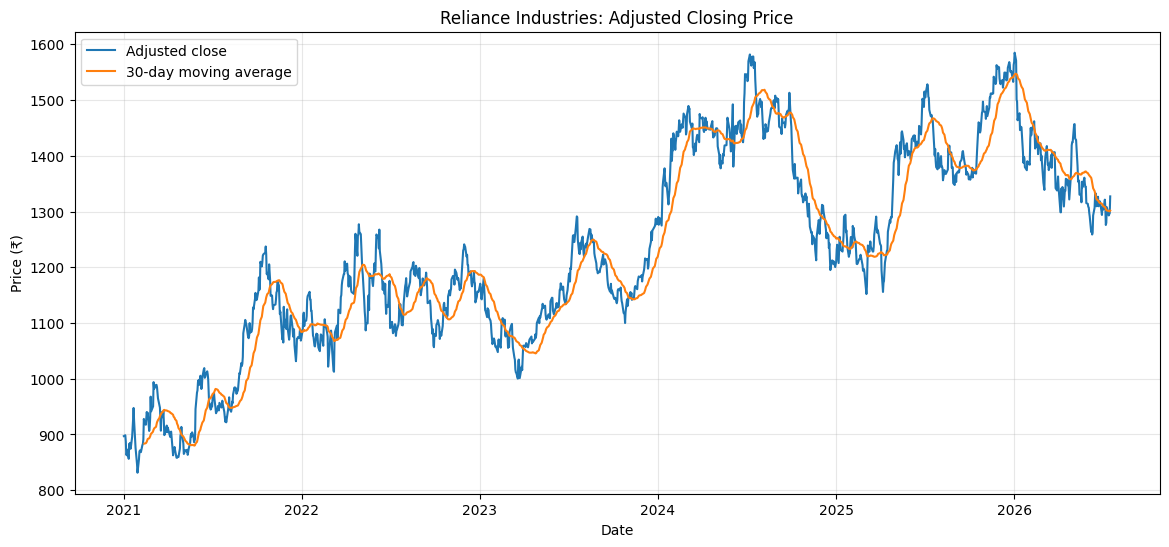

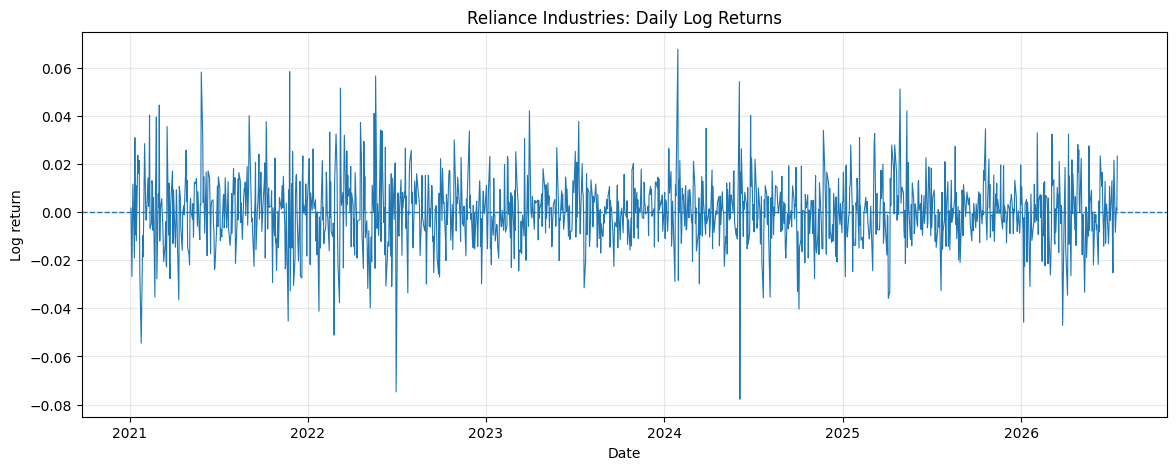

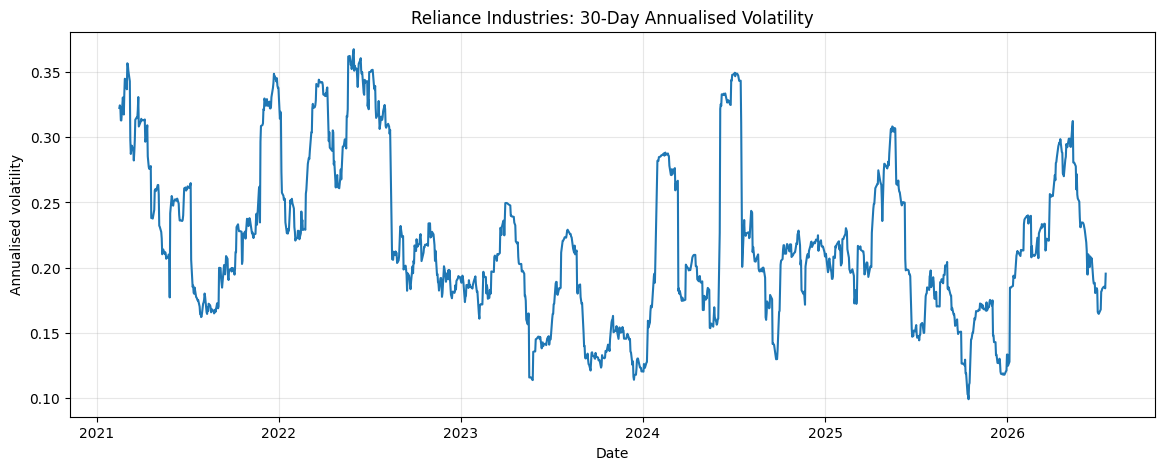

In [5]:
# Historical price and moving average
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Adj Close"], label="Adjusted close")
plt.plot(df.index, df["Rolling_Mean_30"], label="30-day moving average")
plt.title("Reliance Industries: Adjusted Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Daily log returns
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Log_Return"], linewidth=0.8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Reliance Industries: Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log return")
plt.grid(True, alpha=0.3)
plt.show()

# Rolling volatility
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Rolling_Volatility_30"])
plt.title("Reliance Industries: 30-Day Annualised Volatility")
plt.xlabel("Date")
plt.ylabel("Annualised volatility")
plt.grid(True, alpha=0.3)
plt.show()


### Stationarity and autocorrelation

The Augmented Dickey–Fuller test checks whether a series is stationary.

- **p-value < 0.05:** evidence that the series is stationary.
- **p-value ≥ 0.05:** insufficient evidence of stationarity.


In [6]:
def adf_summary(series: pd.Series, name: str) -> dict:
    clean_series = series.dropna()
    statistic, p_value, used_lag, n_obs, *_ = adfuller(clean_series)
    return {
        "Series": name,
        "ADF Statistic": statistic,
        "p-value": p_value,
        "Lags Used": used_lag,
        "Observations": n_obs,
        "Stationary at 5%": p_value < 0.05,
    }


adf_results = pd.DataFrame(
    [
        adf_summary(df["Adj Close"], "Adjusted closing price"),
        adf_summary(df["Log_Return"], "Log returns"),
        adf_summary(df["Price_Difference"], "First-differenced price"),
    ]
)

display(adf_results.round(4))


,Series,ADF Statistic,p-value,Lags Used,Observations,Stationary at 5%
0,Adjusted closing price,-2.2756,0.18,0,1371,False
1,Log returns,-22.5076,0.00,2,1368,True
2,First-differenced price,-36.7645,0.00,0,1370,True


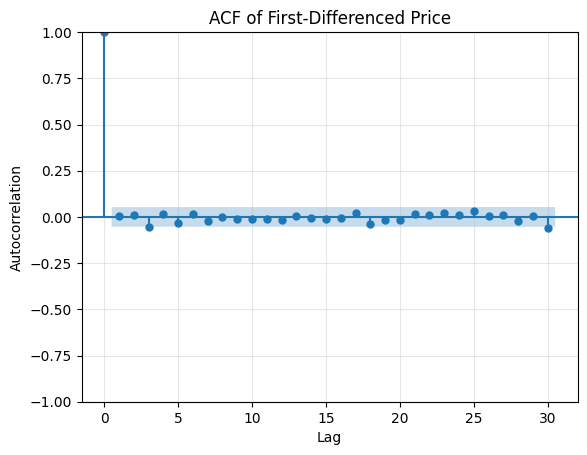

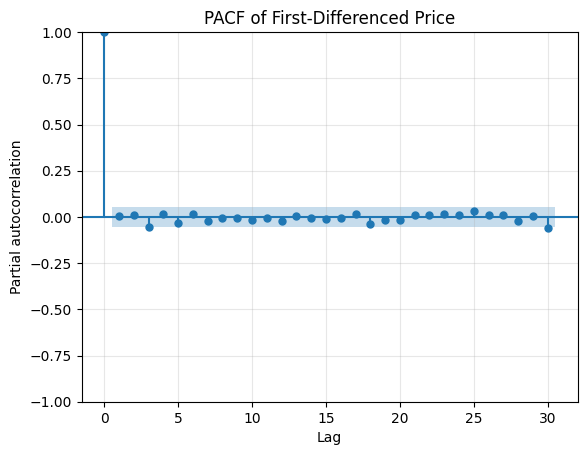

In [7]:
stationary_price = df["Price_Difference"].dropna()

plot_acf(stationary_price, lags=30)
plt.title("ACF of First-Differenced Price")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True, alpha=0.3)
plt.show()

plot_pacf(stationary_price, lags=30, method="ywm")
plt.title("PACF of First-Differenced Price")
plt.xlabel("Lag")
plt.ylabel("Partial autocorrelation")
plt.grid(True, alpha=0.3)
plt.show()


### Trend analysis

STL isolates the long-run trend. A linear slope over the final 90 trading days provides a compact directional description.


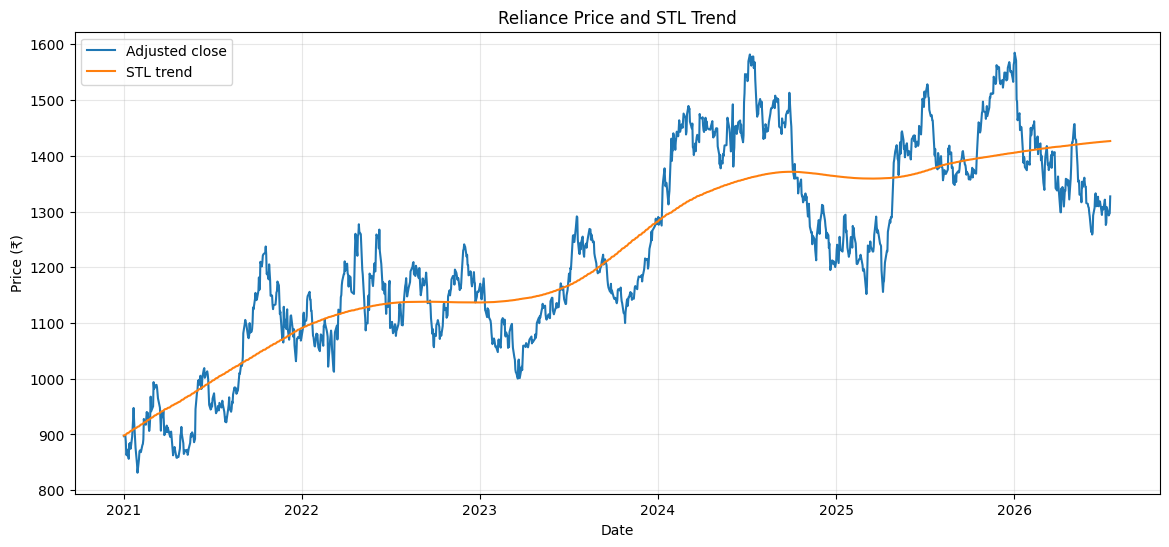

Recent 90-trading-day trend: Upward
Estimated daily trend slope: 0.1419


In [8]:
stl_result = STL(
    df["Adj Close"].dropna(),
    period=TRADING_DAYS,
    robust=True,
).fit()

trend_series = stl_result.trend.dropna()
recent_trend = trend_series.tail(90)
trend_slope = np.polyfit(np.arange(len(recent_trend)), recent_trend.values, 1)[0]
trend_direction = (
    "Upward" if trend_slope > 0 else "Downward" if trend_slope < 0 else "Flat"
)

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Adj Close"], label="Adjusted close")
plt.plot(trend_series.index, trend_series, label="STL trend")
plt.title("Reliance Price and STL Trend")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Recent 90-trading-day trend: {trend_direction}")
print(f"Estimated daily trend slope: {trend_slope:.4f}")


### Time-based train–test split

Time-series observations are never randomly shuffled. Earlier observations form the training set and the latest observations form the test set.


Training observations: 1097
Testing observations: 275
Training period: 2021-01-01 to 2025-06-11
Testing period: 2025-06-12 to 2026-07-17


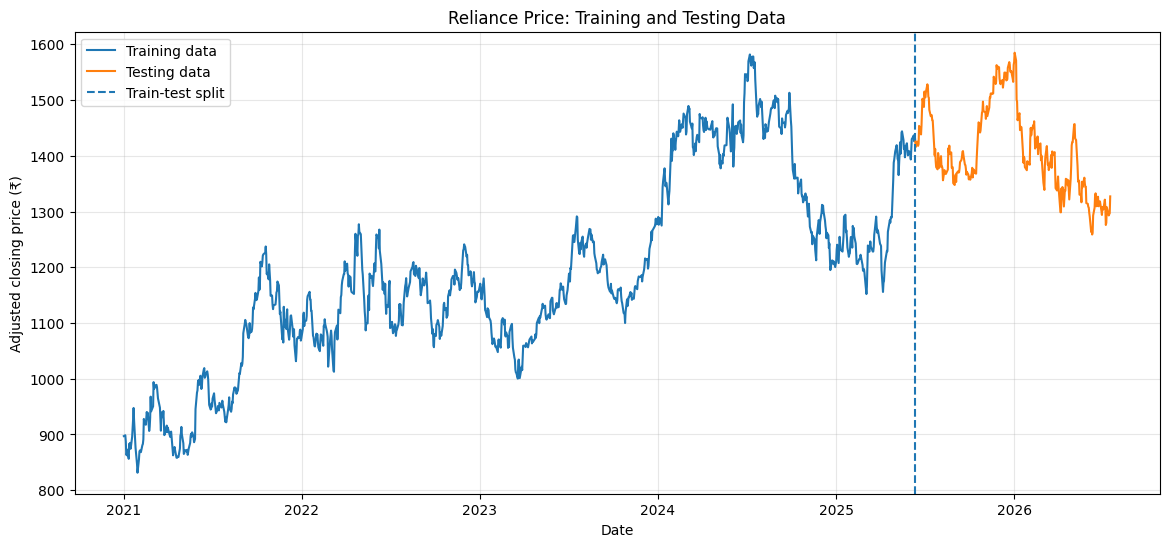

In [9]:
price_series = df["Adj Close"].dropna().astype(float)
split_index = int(len(price_series) * TRAIN_RATIO)

train = price_series.iloc[:split_index]
test = price_series.iloc[split_index:]

print(f"Training observations: {len(train)}")
print(f"Testing observations: {len(test)}")
print(f"Training period: {train.index.min().date()} to {train.index.max().date()}")
print(f"Testing period: {test.index.min().date()} to {test.index.max().date()}")

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Training data")
plt.plot(test.index, test, label="Testing data")
plt.axvline(test.index[0], linestyle="--", label="Train-test split")
plt.title("Reliance Price: Training and Testing Data")
plt.xlabel("Date")
plt.ylabel("Adjusted closing price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Evaluation helpers

In [10]:
def regression_metrics(actual, predicted) -> dict:
    actual_array = np.asarray(actual, dtype=float)
    predicted_array = np.asarray(predicted, dtype=float)

    return {
        "MAE": mean_absolute_error(actual_array, predicted_array),
        "RMSE": np.sqrt(mean_squared_error(actual_array, predicted_array)),
        "MAPE (%)": mean_absolute_percentage_error(actual_array, predicted_array) * 100,
    }


def direction_metrics(actual, predicted, previous_actual) -> dict:
    actual_change = np.asarray(actual, dtype=float) - np.asarray(
        previous_actual, dtype=float
    )
    predicted_change = np.asarray(predicted, dtype=float) - np.asarray(
        previous_actual, dtype=float
    )

    actual_sign = np.sign(actual_change)
    predicted_sign = np.sign(predicted_change)

    valid = (actual_sign != 0) & (predicted_sign != 0)
    coverage = valid.mean() * 100

    if valid.sum() == 0:
        accuracy = np.nan
    else:
        accuracy = (actual_sign[valid] == predicted_sign[valid]).mean() * 100

    return {
        "Directional Accuracy (%)": accuracy,
        "Direction Coverage (%)": coverage,
    }


### ARIMA order selection

The differencing order is fixed at `d = 1` because the price is non-stationary and the first difference is stationary. Small `p` and `q` values are compared using AIC.


In [11]:
order_rows = []

for p in range(3):
    for q in range(3):
        order = (p, 1, q)

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fitted = ARIMA(train.values, order=order).fit()

            order_rows.append(
                {
                    "Order": order,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic,
                }
            )
        except Exception as error:
            print(f"Skipped ARIMA{order}: {error}")

arima_order_table = pd.DataFrame(order_rows).sort_values("AIC").reset_index(drop=True)

best_arima_order = tuple(arima_order_table.loc[0, "Order"])

display(arima_order_table.round(3))
print("Selected ARIMA order:", best_arima_order)


,Order,AIC,BIC
0,"(2, 1, 2)",9378.249,9403.246
1,"(0, 1, 0)",9379.113,9384.112
2,"(1, 1, 2)",9379.555,9399.553
3,"(2, 1, 1)",9379.792,9399.790
4,"(1, 1, 0)",9381.023,9391.021
5,"(0, 1, 1)",9381.026,9391.025
6,"(0, 1, 2)",9382.493,9397.491
7,"(2, 1, 0)",9382.556,9397.554
8,"(1, 1, 1)",9382.992,9397.990


Selected ARIMA order: (2, 1, 2)


### Walk-forward validation

For every test date, the models forecast one day ahead using only information available at that time. The actual observation is then added before the next forecast. This is more realistic than forecasting an entire long test period from a single origin.


In [12]:
def walk_forward_arima(
    train_series: pd.Series,
    test_series: pd.Series,
    order: tuple,
) -> pd.Series:
    history = list(train_series.astype(float).values)
    predictions = []

    for actual in tqdm(test_series.values, desc="Walk-forward ARIMA"):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fitted = ARIMA(history, order=order).fit()

        predictions.append(float(fitted.forecast(1)[0]))
        history.append(float(actual))

    return pd.Series(
        predictions,
        index=test_series.index,
        name="ARIMA",
    )


def walk_forward_ets(
    train_series: pd.Series,
    test_series: pd.Series,
) -> pd.Series:
    history = list(train_series.astype(float).values)
    predictions = []

    for actual in tqdm(test_series.values, desc="Walk-forward ETS"):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fitted = ExponentialSmoothing(
                    np.asarray(history),
                    trend="add",
                    damped_trend=True,
                    seasonal=None,
                    initialization_method="estimated",
                ).fit(
                    optimized=True,
                    use_brute=False,
                )

            prediction = float(fitted.forecast(1)[0])
        except Exception:
            prediction = float(history[-1])

        predictions.append(prediction)
        history.append(float(actual))

    return pd.Series(
        predictions,
        index=test_series.index,
        name="ETS",
    )


Walk-forward ARIMA:   0%|          | 0/275 [00:00<?, ?it/s]

Walk-forward ETS:   0%|          | 0/275 [00:00<?, ?it/s]

,Model,MAE,RMSE,MAPE (%),Directional Accuracy (%),Direction Coverage (%)
0,ARIMA-ETS Ensemble,12.927,17.641,0.922,52.593,98.182
1,Naive,12.946,17.646,0.923,NaN,0.000
2,ETS,12.946,17.646,0.923,52.045,97.818
3,"ARIMA(2, 1, 2)",12.980,17.674,0.926,52.593,98.182


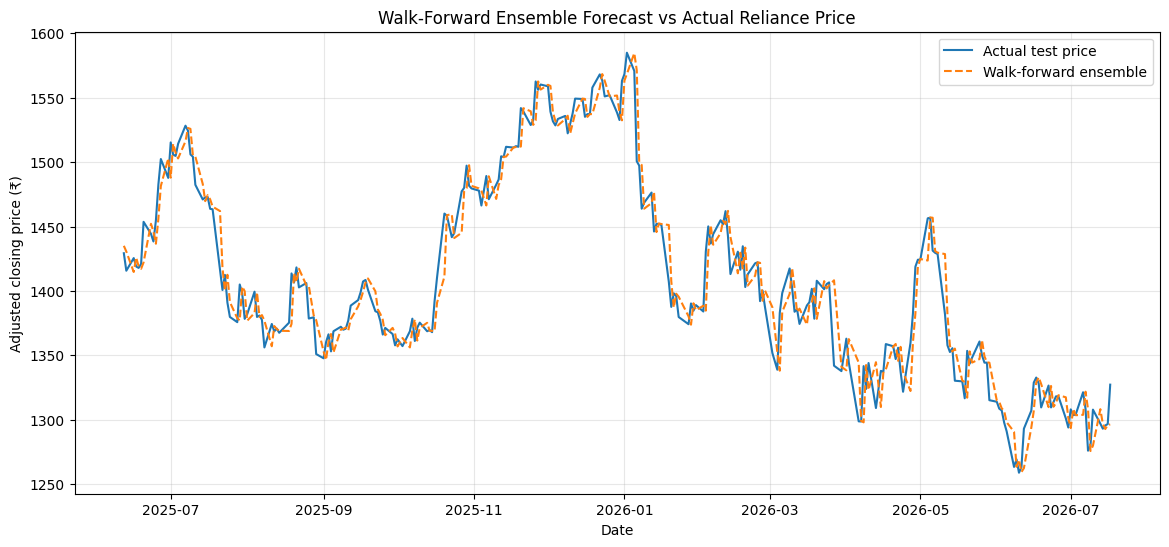

In [13]:
# Strong one-step naive baseline: today's forecast equals the previous actual price
previous_actual = pd.Series(index=test.index, dtype=float)
previous_actual.iloc[0] = train.iloc[-1]
previous_actual.iloc[1:] = test.iloc[:-1].values

walk_naive = previous_actual.rename("Naive")
walk_arima = walk_forward_arima(train, test, best_arima_order)
walk_ets = walk_forward_ets(train, test)
walk_ensemble = ((walk_arima + walk_ets) / 2).rename("ARIMA-ETS Ensemble")

walk_forecasts = {
    "Naive": walk_naive,
    f"ARIMA{best_arima_order}": walk_arima,
    "ETS": walk_ets,
    "ARIMA-ETS Ensemble": walk_ensemble,
}

walk_rows = []

for model_name, prediction in walk_forecasts.items():
    walk_rows.append(
        {
            "Model": model_name,
            **regression_metrics(test, prediction),
            **direction_metrics(test, prediction, previous_actual),
        }
    )

walk_forward_comparison = (
    pd.DataFrame(walk_rows).sort_values("RMSE").reset_index(drop=True)
)

display(walk_forward_comparison.round(3))

plt.figure(figsize=(14, 6))
plt.plot(test.index, test, label="Actual test price")
plt.plot(
    walk_ensemble.index,
    walk_ensemble,
    linestyle="--",
    label="Walk-forward ensemble",
)
plt.title("Walk-Forward Ensemble Forecast vs Actual Reliance Price")
plt.xlabel("Date")
plt.ylabel("Adjusted closing price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Residual diagnostics

Residuals are calculated as $e_t = y_t - \hat{y}_t$. The Ljung–Box test checks whether meaningful residual autocorrelation remains.


Residual summary


,Value
count,275.0000
mean,-0.3991
std,17.6684
min,-70.7213
25%,-11.3853
50%,-0.3936
75%,9.2804
max,48.9701


Ljung-Box test


,lb_stat,lb_pvalue
10,4.887,0.8986
20,14.239,0.8182


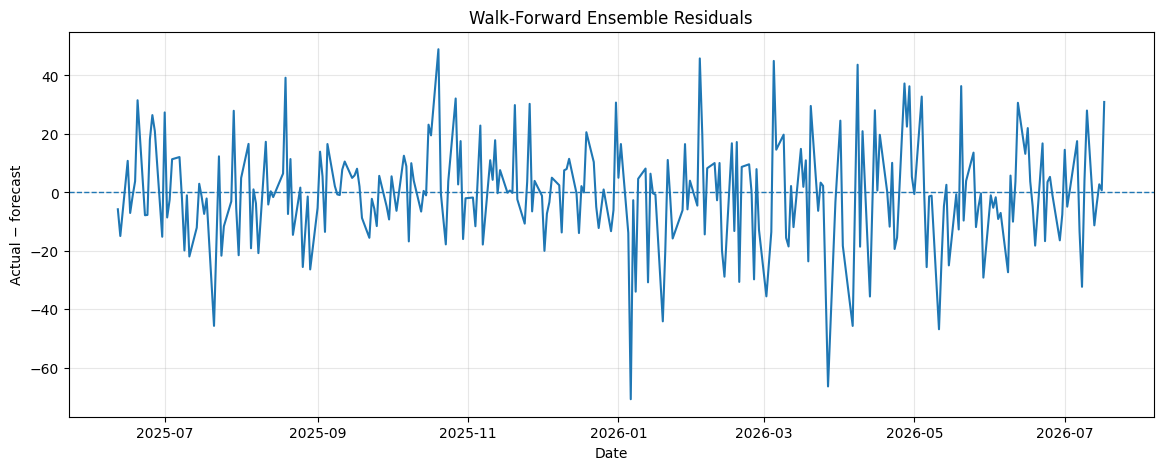

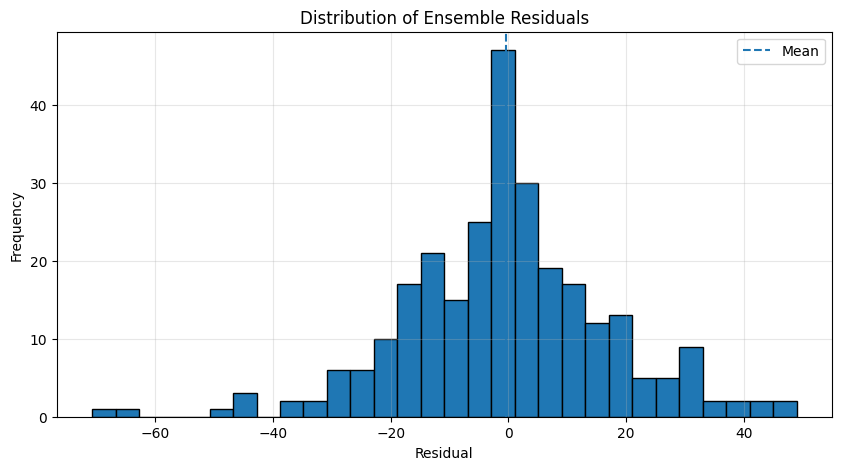

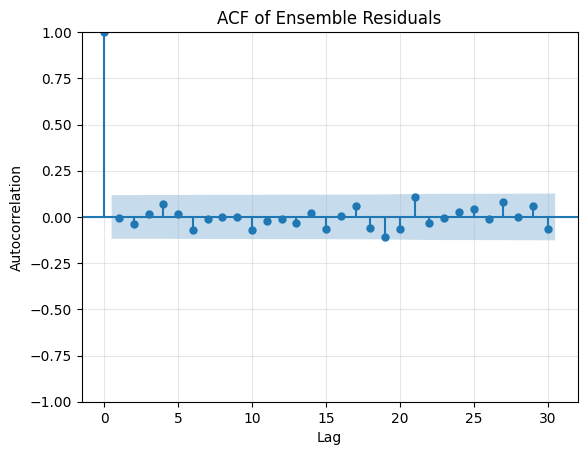

In [14]:
ensemble_residuals = (test - walk_ensemble).rename("Residual")

residual_summary = ensemble_residuals.describe().to_frame("Value")
ljung_box_results = acorr_ljungbox(
    ensemble_residuals.dropna(),
    lags=[10, 20],
    return_df=True,
)

print("Residual summary")
display(residual_summary.round(4))

print("Ljung-Box test")
display(ljung_box_results.round(4))

plt.figure(figsize=(14, 5))
plt.plot(ensemble_residuals.index, ensemble_residuals)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Walk-Forward Ensemble Residuals")
plt.xlabel("Date")
plt.ylabel("Actual − forecast")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(ensemble_residuals.dropna(), bins=30, edgecolor="black")
plt.axvline(ensemble_residuals.mean(), linestyle="--", label="Mean")
plt.title("Distribution of Ensemble Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plot_acf(ensemble_residuals.dropna(), lags=30)
plt.title("ACF of Ensemble Residuals")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True, alpha=0.3)
plt.show()


### Optional advanced extension: ARCH and GARCH

The ARCH-LM test checks whether return variance changes over time. When ARCH effects are present, GARCH(1,1) is used to model conditional volatility.


,Statistic,Value
0,LM statistic,28.604911
1,LM p-value,0.001443
2,F statistic,2.908116
3,F p-value,0.001342


ARCH effects present:


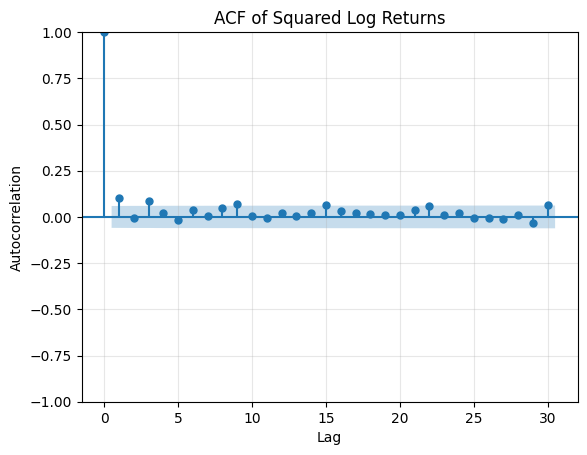

,Estimate
mu,0.0433
omega,0.0633
alpha[1],0.0406
beta[1],0.9298


GARCH persistence (alpha + beta): 0.9704


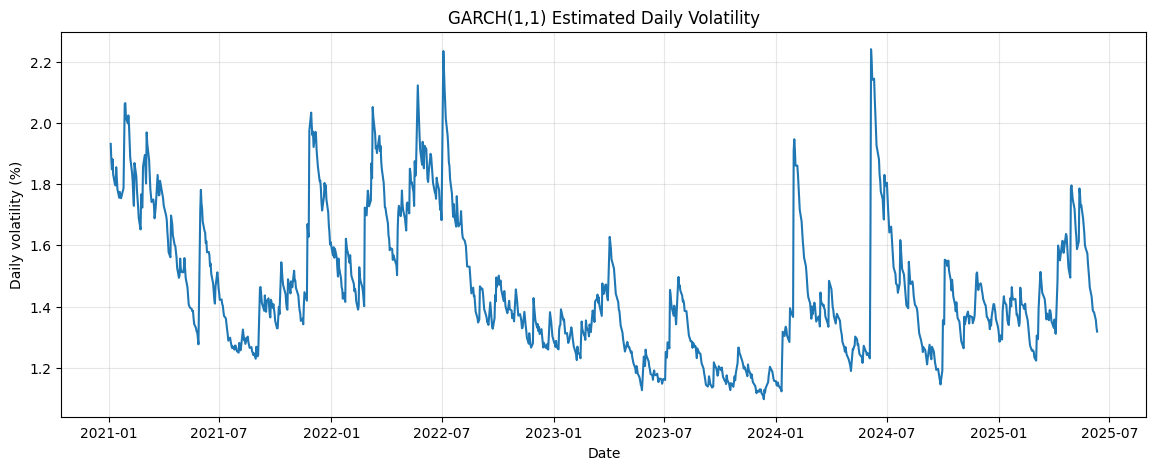

In [15]:
train_log_returns_pct = df.loc[train.index, "Log_Return"].dropna().astype(float) * 100

arch_lm = het_arch(train_log_returns_pct, nlags=10)

arch_test_table = pd.DataFrame(
    {
        "Statistic": [
            "LM statistic",
            "LM p-value",
            "F statistic",
            "F p-value",
        ],
        "Value": arch_lm,
    }
)

display(arch_test_table.round(6))
print(
    "ARCH effects present:"
    if arch_lm[1] < 0.05
    else "No statistically significant ARCH effects detected."
)

plot_acf(train_log_returns_pct**2, lags=30)
plt.title("ACF of Squared Log Returns")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True, alpha=0.3)
plt.show()

garch_fit = arch_model(
    train_log_returns_pct,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal",
).fit(disp="off")

garch_parameters = garch_fit.params.to_frame("Estimate")
garch_persistence = garch_fit.params.get("alpha[1]", np.nan) + garch_fit.params.get(
    "beta[1]", np.nan
)

display(garch_parameters.round(4))
print(f"GARCH persistence (alpha + beta): {garch_persistence:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(garch_fit.conditional_volatility.index, garch_fit.conditional_volatility)
plt.title("GARCH(1,1) Estimated Daily Volatility")
plt.xlabel("Date")
plt.ylabel("Daily volatility (%)")
plt.grid(True, alpha=0.3)
plt.show()


### Future volatility forecast

,Date,Daily Volatility (%),Annualised Volatility (%)
0,2026-07-20,1.321,20.971
1,2026-07-21,1.324,21.017
2,2026-07-22,1.327,21.061
3,2026-07-23,1.329,21.104
4,2026-07-24,1.332,21.146
5,2026-07-27,1.335,21.186
6,2026-07-28,1.337,21.226
7,2026-07-29,1.340,21.264
8,2026-07-30,1.342,21.301
9,2026-07-31,1.344,21.337


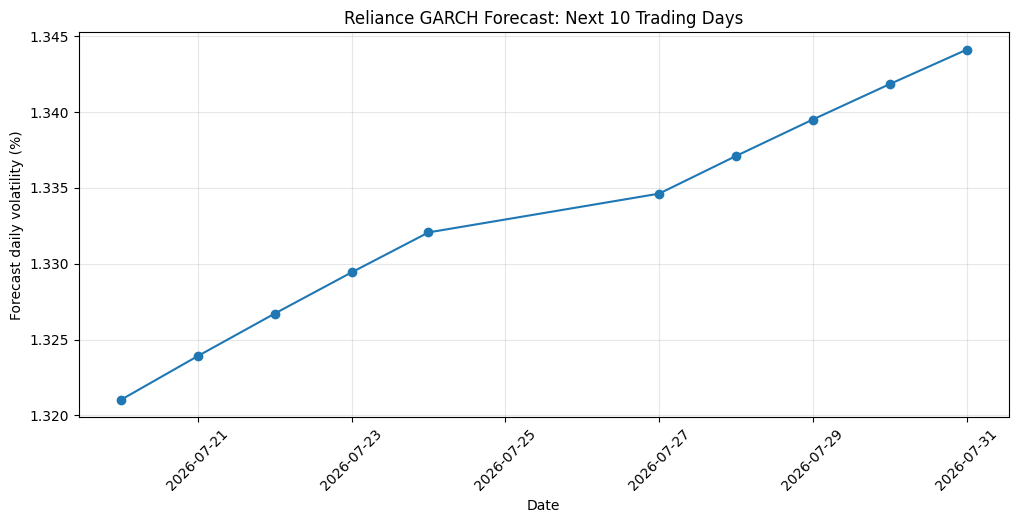

In [16]:
full_log_returns_pct = df["Log_Return"].dropna().astype(float) * 100

final_garch_fit = arch_model(
    full_log_returns_pct,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal",
).fit(disp="off")

garch_future = final_garch_fit.forecast(
    horizon=FORECAST_HORIZON,
    reindex=False,
)

future_daily_volatility = np.sqrt(garch_future.variance.iloc[-1].to_numpy())

future_dates = pd.bdate_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON,
)

future_volatility_table = pd.DataFrame(
    {
        "Date": future_dates,
        "Daily Volatility (%)": future_daily_volatility,
        "Annualised Volatility (%)": (future_daily_volatility * np.sqrt(TRADING_DAYS)),
    }
)

display(future_volatility_table.round(3))

plt.figure(figsize=(12, 5))
plt.plot(
    future_volatility_table["Date"],
    future_volatility_table["Daily Volatility (%)"],
    marker="o",
)
plt.title(f"Reliance GARCH Forecast: Next {FORECAST_HORIZON} Trading Days")
plt.xlabel("Date")
plt.ylabel("Forecast daily volatility (%)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()


### Future price forecast

ARIMA and ETS are refitted using the complete fixed dataset and their point forecasts are averaged. The business-day dates exclude weekends but may include an NSE holiday.


,Date,ARIMA Forecast,ETS Forecast,Ensemble Forecast,ARIMA Lower 95%,ARIMA Upper 95%,Expected Return from Last Price (%)
0,2026-07-20,1328.03,1327.20,1327.62,1293.84,1362.23,0.03
1,2026-07-21,1328.26,1327.20,1327.73,1279.65,1376.87,0.04
2,2026-07-22,1327.50,1327.20,1327.35,1267.49,1387.51,0.01
3,2026-07-23,1328.43,1327.21,1327.82,1259.40,1397.46,0.05
4,2026-07-24,1327.55,1327.21,1327.38,1250.04,1405.06,0.01
5,2026-07-27,1328.26,1327.21,1327.74,1243.52,1413.01,0.04
6,2026-07-28,1327.75,1327.21,1327.48,1236.06,1419.45,0.02
7,2026-07-29,1328.07,1327.21,1327.64,1230.10,1426.05,0.03
8,2026-07-30,1327.90,1327.21,1327.56,1223.93,1431.88,0.03
9,2026-07-31,1327.97,1327.21,1327.59,1218.37,1437.56,0.03


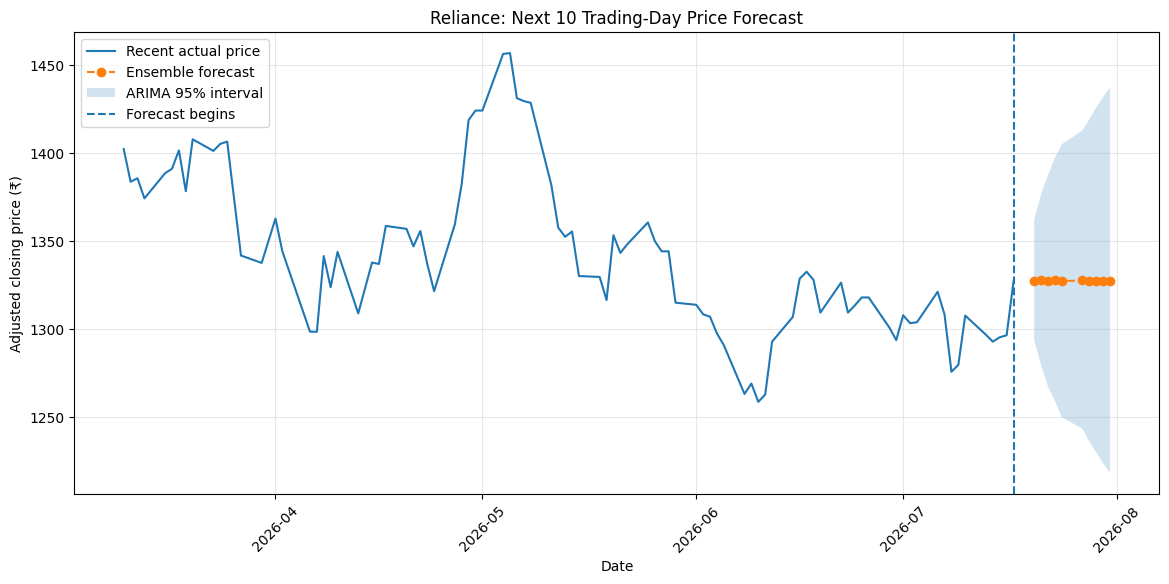

In [17]:
full_price = df["Adj Close"].dropna().astype(float)

future_dates = pd.bdate_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_arima_fit = ARIMA(
        full_price.values,
        order=best_arima_order,
    ).fit()

final_ets_fit = ExponentialSmoothing(
    full_price.values,
    trend="add",
    damped_trend=True,
    seasonal=None,
    initialization_method="estimated",
).fit(optimized=True)

arima_result = final_arima_fit.get_forecast(steps=FORECAST_HORIZON)
arima_future = np.asarray(arima_result.predicted_mean, dtype=float)
arima_confidence = np.asarray(
    arima_result.conf_int(alpha=0.05),
    dtype=float,
)

ets_future = np.asarray(
    final_ets_fit.forecast(FORECAST_HORIZON),
    dtype=float,
)

ensemble_future = (arima_future + ets_future) / 2
last_actual_price = float(full_price.iloc[-1])

future_price_table = pd.DataFrame(
    {
        "Date": future_dates,
        "ARIMA Forecast": arima_future,
        "ETS Forecast": ets_future,
        "Ensemble Forecast": ensemble_future,
        "ARIMA Lower 95%": arima_confidence[:, 0],
        "ARIMA Upper 95%": arima_confidence[:, 1],
    }
)

future_price_table["Expected Return from Last Price (%)"] = (
    future_price_table["Ensemble Forecast"] / last_actual_price - 1
) * 100

display(future_price_table.round(2))

recent_price = full_price.tail(90)

plt.figure(figsize=(14, 6))
plt.plot(recent_price.index, recent_price, label="Recent actual price")
plt.plot(
    future_price_table["Date"],
    future_price_table["Ensemble Forecast"],
    marker="o",
    linestyle="--",
    label="Ensemble forecast",
)
plt.fill_between(
    future_price_table["Date"],
    future_price_table["ARIMA Lower 95%"],
    future_price_table["ARIMA Upper 95%"],
    alpha=0.2,
    label="ARIMA 95% interval",
)
plt.axvline(full_price.index[-1], linestyle="--", label="Forecast begins")
plt.title(f"Reliance: Next {FORECAST_HORIZON} Trading-Day Price Forecast")
plt.xlabel("Date")
plt.ylabel("Adjusted closing price (₹)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()


### Reliance case-study summary

In [18]:
best_walk_row = walk_forward_comparison.iloc[0]
ensemble_direction = direction_metrics(
    test,
    walk_ensemble,
    previous_actual,
)

final_price_forecast = float(future_price_table["Ensemble Forecast"].iloc[-1])

expected_horizon_return = (final_price_forecast / last_actual_price - 1) * 100

final_summary = pd.DataFrame(
    {
        "Metric": [
            "Stock",
            "Data period",
            "Selected ARIMA order",
            "Best walk-forward model",
            "Best walk-forward RMSE",
            "Best walk-forward MAPE",
            "Ensemble directional accuracy",
            "Last actual adjusted closing price",
            f"Final {FORECAST_HORIZON}-day ensemble forecast",
            f"Expected {FORECAST_HORIZON}-day return",
            "Average forecast daily volatility",
            "Average forecast annualised volatility",
            "Recent 90-day trend",
        ],
        "Value": [
            TICKER,
            f"{df.index.min().date()} to {df.index.max().date()}",
            str(best_arima_order),
            best_walk_row["Model"],
            f"{best_walk_row['RMSE']:.2f}",
            f"{best_walk_row['MAPE (%)']:.2f}%",
            (
                f"{ensemble_direction['Directional Accuracy (%)']:.2f}%"
                if not np.isnan(ensemble_direction["Directional Accuracy (%)"])
                else "Not available"
            ),
            f"₹{last_actual_price:.2f}",
            f"₹{final_price_forecast:.2f}",
            f"{expected_horizon_return:.2f}%",
            f"{future_volatility_table['Daily Volatility (%)'].mean():.2f}%",
            f"{future_volatility_table['Annualised Volatility (%)'].mean():.2f}%",
            trend_direction,
        ],
    }
)

display(final_summary)

print("Reliance case-study summary created successfully.")


,Metric,Value
0,Stock,RELIANCE.NS
1,Data period,2021-01-01 to 2026-07-17
2,Selected ARIMA order,"(2, 1, 2)"
3,Best walk-forward model,ARIMA-ETS Ensemble
4,Best walk-forward RMSE,17.64
5,Best walk-forward MAPE,0.92%
6,Ensemble directional accuracy,52.59%
7,Last actual adjusted closing price,₹1327.20
8,Final 10-day ensemble forecast,₹1327.59
9,Expected 10-day return,0.03%


Reliance case-study summary created successfully.


### Reliance interpretation

- Adjusted prices are non-stationary, while log returns and first differences are stationary.
- Walk-forward validation is the primary evaluation because it respects the time ordering of the data.
- ARIMA, ETS and ensemble models should always be compared with the previous-price naive baseline.
- Directional accuracy near 50% indicates limited trading-direction information in price history alone.
- GARCH is useful for modelling changing risk even when mean-price forecasting is difficult.
- Point forecasts must be interpreted together with uncertainty and volatility.

The next section applies a shorter version of this workflow to multiple NSE stocks and constructs portfolios.


# Part 2 — Multi-Stock Forecasting and Portfolio Analysis

Eight NSE stocks are analysed with one reusable pipeline. The final portfolio combines forecast information with volatility-aware risk control.


In [19]:
# ============================================================
# MULTI-STOCK UNIVERSE AND DATA COLLECTION
# ============================================================

stock_information = {
    "RELIANCE.NS": {
        "Company": "Reliance Industries",
        "Sector": "Energy",
    },
    "HDFCBANK.NS": {
        "Company": "HDFC Bank",
        "Sector": "Banking",
    },
    "TCS.NS": {
        "Company": "Tata Consultancy Services",
        "Sector": "Information Technology",
    },
    "SUNPHARMA.NS": {
        "Company": "Sun Pharmaceutical",
        "Sector": "Pharmaceuticals",
    },
    "MARUTI.NS": {
        "Company": "Maruti Suzuki",
        "Sector": "Automobile",
    },
    "HINDUNILVR.NS": {
        "Company": "Hindustan Unilever",
        "Sector": "FMCG",
    },
    "ADANIENT.NS": {
        "Company": "Adani Enterprises",
        "Sector": "Infrastructure",
    },
    "WIPRO.NS": {
        "Company": "Wipro",
        "Sector": "Information Technology",
    },
}

stock_tickers = list(stock_information.keys())

# Download all stocks using the same fixed dates as Reliance
multi_stock_raw = yf.download(
    stock_tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
    threads=True,
)

if multi_stock_raw.empty:
    raise RuntimeError("No multi-stock data was downloaded.")

# Extract adjusted closing prices
if isinstance(multi_stock_raw.columns, pd.MultiIndex):
    if "Adj Close" in multi_stock_raw.columns.get_level_values(0):
        multi_stock_prices = multi_stock_raw["Adj Close"].copy()
    else:
        multi_stock_prices = multi_stock_raw["Close"].copy()
else:
    raise ValueError("Unexpected column structure in downloaded multi-stock data.")

# Clean and arrange the dataset. Leading incomplete rows are dropped
# rather than backward-filled, which avoids using future information.
multi_stock_prices = (
    multi_stock_prices.sort_index()
    .reindex(columns=stock_tickers)
    .ffill()
    .dropna(how="any")
)

multi_stock_prices.columns.name = None

# Create the stock-information table
stock_information_table = pd.DataFrame.from_dict(
    stock_information,
    orient="index",
).reset_index(names="Ticker")

print("Multi-stock data downloaded successfully.")
print("Dataset shape:", multi_stock_prices.shape)
print(
    "Period:",
    multi_stock_prices.index.min().date(),
    "to",
    multi_stock_prices.index.max().date(),
)
print(
    "Total missing values:",
    int(multi_stock_prices.isna().sum().sum()),
)

display(stock_information_table)
display(multi_stock_prices.head())


Multi-stock data downloaded successfully.
Dataset shape: (1372, 8)
Period: 2021-01-01 to 2026-07-17
Total missing values: 0


,Ticker,Company,Sector
0,RELIANCE.NS,Reliance Industries,Energy
1,HDFCBANK.NS,HDFC Bank,Banking
2,TCS.NS,Tata Consultancy Services,Information Technology
3,SUNPHARMA.NS,Sun Pharmaceutical,Pharmaceuticals
4,MARUTI.NS,Maruti Suzuki,Automobile
5,HINDUNILVR.NS,Hindustan Unilever,FMCG
6,ADANIENT.NS,Adani Enterprises,Infrastructure
7,WIPRO.NS,Wipro,Information Technology


,RELIANCE.NS,HDFCBANK.NS,TCS.NS,SUNPHARMA.NS,MARUTI.NS,HINDUNILVR.NS,ADANIENT.NS,WIPRO.NS
Date,,,,,,,,
2021-01-01,897.047119,663.905762,2521.074219,561.122253,7371.631836,2173.496094,489.740875,178.880478
2021-01-04,898.559143,659.689514,2616.811523,568.792114,7382.174805,2208.954102,493.081268,182.706055
2021-01-05,887.388245,664.674377,2662.915527,567.898071,7337.271973,2230.848145,492.981567,187.269089
2021-01-06,863.986084,661.809143,2627.186279,569.639038,7311.537598,2200.578857,489.491608,187.315186
2021-01-07,862.586975,659.805969,2611.086182,566.439514,7251.587402,2156.472412,516.613525,187.476532


## Multi-stock diagnostics

Calculate returns, ADF stationarity results and recent annualised volatility for all stocks in one table.


In [20]:
# ============================================================
# MULTI-STOCK RETURNS, STATIONARITY AND VOLATILITY
# ============================================================

# Calculate percentage and logarithmic returns
multi_stock_returns = multi_stock_prices.pct_change().dropna()

multi_stock_log_returns = np.log(
    multi_stock_prices / multi_stock_prices.shift(1)
).dropna()

multi_stock_summary_rows = []

for ticker in stock_tickers:

    price_series = multi_stock_prices[ticker].dropna().astype(float)

    log_return_series = multi_stock_log_returns[ticker].dropna().astype(float)

    # ADF stationarity tests
    price_adf_result = adfuller(price_series)
    return_adf_result = adfuller(log_return_series)

    # Latest rolling annualised volatility
    volatility_30d = log_return_series.tail(30).std() * np.sqrt(252) * 100

    volatility_90d = log_return_series.tail(90).std() * np.sqrt(252) * 100

    multi_stock_summary_rows.append(
        {
            "Ticker": ticker,
            "Company": stock_information[ticker]["Company"],
            "Sector": stock_information[ticker]["Sector"],
            "Latest Price": price_series.iloc[-1],
            "Price ADF p-value": price_adf_result[1],
            "Price Stationary": ("Yes" if price_adf_result[1] < 0.05 else "No"),
            "Return ADF p-value": return_adf_result[1],
            "Return Stationary": ("Yes" if return_adf_result[1] < 0.05 else "No"),
            "30-Day Volatility (%)": volatility_30d,
            "90-Day Volatility (%)": volatility_90d,
        }
    )


multi_stock_summary = pd.DataFrame(multi_stock_summary_rows)

display(
    multi_stock_summary.round(
        {
            "Latest Price": 2,
            "Price ADF p-value": 4,
            "Return ADF p-value": 4,
            "30-Day Volatility (%)": 2,
            "90-Day Volatility (%)": 2,
        }
    )
)

print("All price and return analyses completed successfully.")


,Ticker,Company,Sector,Latest Price,Price ADF p-value,Price Stationary,Return ADF p-value,Return Stationary,30-Day Volatility (%),90-Day Volatility (%)
0,RELIANCE.NS,Reliance Industries,Energy,1327.2,0.1800,No,0.0,Yes,19.55,23.18
1,HDFCBANK.NS,HDFC Bank,Banking,819.6,0.2253,No,0.0,Yes,20.92,28.58
2,TCS.NS,Tata Consultancy Services,Information Technology,2269.0,0.5109,No,0.0,Yes,33.10,33.29
3,SUNPHARMA.NS,Sun Pharmaceutical,Pharmaceuticals,1932.6,0.8571,No,0.0,Yes,12.52,21.98
4,MARUTI.NS,Maruti Suzuki,Automobile,13803.0,0.7737,No,0.0,Yes,29.37,28.72
5,HINDUNILVR.NS,Hindustan Unilever,FMCG,2143.8,0.0311,Yes,0.0,Yes,20.31,23.26
6,ADANIENT.NS,Adani Enterprises,Infrastructure,3160.7,0.0861,No,0.0,Yes,27.90,36.86
7,WIPRO.NS,Wipro,Information Technology,176.0,0.3711,No,0.0,Yes,32.33,27.92


All price and return analyses completed successfully.


## Reusable forecasting pipeline

The functions below prevent repeated code. Each stock receives the same train–test split, ARIMA search, walk-forward evaluation, two-day forecast and volatility calculation.


In [21]:
# ============================================================
# REUSABLE MULTI-STOCK FORECASTING FUNCTIONS
# ============================================================

# State-space ETS is imported in the setup cell and supports fast updates.


def calculate_forecast_metrics(actual, predicted):
    """Calculate price-forecasting error metrics."""

    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAPE (%)": (
            mean_absolute_percentage_error(
                actual,
                predicted,
            )
            * 100
        ),
    }


def calculate_directional_accuracy(
    actual,
    predicted,
    previous_actual,
):
    """Calculate up/down directional accuracy."""

    actual_change = np.asarray(actual) - np.asarray(previous_actual)

    predicted_change = np.asarray(predicted) - np.asarray(previous_actual)

    actual_direction = np.sign(actual_change)
    predicted_direction = np.sign(predicted_change)

    valid_direction = (actual_direction != 0) & (predicted_direction != 0)

    coverage = valid_direction.mean() * 100

    if valid_direction.sum() == 0:
        return np.nan, coverage

    accuracy = (
        actual_direction[valid_direction] == predicted_direction[valid_direction]
    ).mean() * 100

    return accuracy, coverage


def select_best_arima_order(train_series):
    """Select ARIMA(p,1,q) using minimum AIC."""

    candidate_results = []

    for p in range(3):
        for q in range(3):

            order = (p, 1, q)

            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")

                    model = ARIMA(
                        train_series,
                        order=order,
                    )

                    fitted_model = model.fit()

                candidate_results.append(
                    {
                        "Order": order,
                        "AIC": fitted_model.aic,
                    }
                )

            except Exception:
                continue

    if not candidate_results:
        return (0, 1, 0)

    candidate_table = pd.DataFrame(candidate_results).sort_values("AIC")

    return candidate_table.iloc[0]["Order"]


def analyse_single_stock(
    ticker,
    price_series,
    company,
    sector,
    test_fraction=0.20,
    future_horizon=2,
):
    """
    Run the complete forecasting pipeline for one stock.

    Returns
    -------
    summary : dict
        Final stock-level forecasting and risk results.

    forecast_details : DataFrame
        Actual and walk-forward predictions.
    """

    series = pd.Series(price_series).dropna().astype(float).sort_index()

    split_index = int(len(series) * (1 - test_fraction))

    train = series.iloc[:split_index]
    test = series.iloc[split_index:]

    train_values = train.values
    test_values = test.values

    # --------------------------------------------------------
    # Previous actual price and naive forecast
    # --------------------------------------------------------

    previous_actual = np.concatenate(
        [
            [train_values[-1]],
            test_values[:-1],
        ]
    )

    naive_forecast = previous_actual.copy()

    # --------------------------------------------------------
    # Select ARIMA order
    # --------------------------------------------------------

    best_arima_order = select_best_arima_order(train_values)

    # --------------------------------------------------------
    # Walk-forward ARIMA
    # --------------------------------------------------------

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        arima_result = ARIMA(
            train_values,
            order=best_arima_order,
        ).fit()

    arima_predictions = []

    for actual_value in test_values:

        prediction = float(arima_result.forecast(1)[0])

        arima_predictions.append(prediction)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            arima_result = arima_result.append(
                [actual_value],
                refit=False,
            )

    arima_predictions = np.asarray(arima_predictions)

    # --------------------------------------------------------
    # Walk-forward ETS
    # --------------------------------------------------------

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        ets_result = StateSpaceETS(
            train_values,
            trend=True,
            damped_trend=True,
            initialization_method="estimated",
        ).fit(disp=False)

    ets_predictions = []

    for actual_value in test_values:

        prediction = float(ets_result.forecast(1)[0])

        ets_predictions.append(prediction)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            ets_result = ets_result.append(
                [actual_value],
                refit=False,
            )

    ets_predictions = np.asarray(ets_predictions)

    # --------------------------------------------------------
    # Ensemble
    # --------------------------------------------------------

    ensemble_predictions = (arima_predictions + ets_predictions) / 2

    # --------------------------------------------------------
    # Evaluation metrics
    # --------------------------------------------------------

    naive_metrics = calculate_forecast_metrics(
        test_values,
        naive_forecast,
    )

    arima_metrics = calculate_forecast_metrics(
        test_values,
        arima_predictions,
    )

    ets_metrics = calculate_forecast_metrics(
        test_values,
        ets_predictions,
    )

    ensemble_metrics = calculate_forecast_metrics(
        test_values,
        ensemble_predictions,
    )

    arima_direction, arima_coverage = calculate_directional_accuracy(
        test_values,
        arima_predictions,
        previous_actual,
    )

    ets_direction, ets_coverage = calculate_directional_accuracy(
        test_values,
        ets_predictions,
        previous_actual,
    )

    ensemble_direction, ensemble_coverage = calculate_directional_accuracy(
        test_values,
        ensemble_predictions,
        previous_actual,
    )

    # --------------------------------------------------------
    # Final two-day forecast using the complete series
    # --------------------------------------------------------

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        final_arima = ARIMA(
            series.values,
            order=best_arima_order,
        ).fit()

        final_ets = StateSpaceETS(
            series.values,
            trend=True,
            damped_trend=True,
            initialization_method="estimated",
        ).fit(disp=False)

    arima_future = np.asarray(final_arima.forecast(future_horizon))

    ets_future = np.asarray(final_ets.forecast(future_horizon))

    ensemble_future = (arima_future + ets_future) / 2

    latest_price = series.iloc[-1]

    expected_return = ((ensemble_future[-1] / latest_price) - 1) * 100

    # --------------------------------------------------------
    # Risk and trend
    # --------------------------------------------------------

    log_returns = np.log(series / series.shift(1)).dropna()

    volatility_30d = log_returns.tail(30).std() * np.sqrt(252) * 100

    volatility_90d = log_returns.tail(90).std() * np.sqrt(252) * 100

    trend_window = series.tail(90)

    trend_slope = np.polyfit(
        np.arange(len(trend_window)),
        trend_window.values,
        1,
    )[0]

    trend_direction = "Upward" if trend_slope > 0 else "Downward"

    # --------------------------------------------------------
    # Final summary
    # --------------------------------------------------------

    summary = {
        "Ticker": ticker,
        "Company": company,
        "Sector": sector,
        "Latest Price": latest_price,
        "Best ARIMA Order": str(best_arima_order),
        "Naive RMSE": naive_metrics["RMSE"],
        "ARIMA RMSE": arima_metrics["RMSE"],
        "ETS RMSE": ets_metrics["RMSE"],
        "Ensemble RMSE": ensemble_metrics["RMSE"],
        "Ensemble MAPE (%)": (ensemble_metrics["MAPE (%)"]),
        "ARIMA Direction (%)": arima_direction,
        "ETS Direction (%)": ets_direction,
        "Ensemble Direction (%)": (ensemble_direction),
        "Direction Coverage (%)": (ensemble_coverage),
        "Day 1 Forecast": ensemble_future[0],
        "Day 2 Forecast": ensemble_future[-1],
        "Expected Return (%)": expected_return,
        "30-Day Volatility (%)": volatility_30d,
        "90-Day Volatility (%)": volatility_90d,
        "Trend": trend_direction,
    }

    forecast_details = pd.DataFrame(
        {
            "Actual": test_values,
            "Naive": naive_forecast,
            "ARIMA": arima_predictions,
            "ETS": ets_predictions,
            "Ensemble": ensemble_predictions,
        },
        index=test.index,
    )

    return summary, forecast_details


print("Reusable multi-stock forecasting functions created successfully.")


Reusable multi-stock forecasting functions created successfully.


## Run ARIMA, ETS and ensemble models for all stocks

In [22]:
# ============================================================
# RUN FORECASTING PIPELINE FOR ALL STOCKS
# ============================================================

multi_stock_results = []
multi_stock_forecasts = {}
failed_stocks = []

for ticker in tqdm(
    stock_tickers,
    desc="Analysing stocks",
):

    try:
        summary, forecast_details = analyse_single_stock(
            ticker=ticker,
            price_series=multi_stock_prices[ticker],
            company=stock_information[ticker]["Company"],
            sector=stock_information[ticker]["Sector"],
            test_fraction=0.20,
            future_horizon=2,
        )

        multi_stock_results.append(summary)
        multi_stock_forecasts[ticker] = forecast_details

    except Exception as error:
        failed_stocks.append(
            {
                "Ticker": ticker,
                "Error": str(error),
            }
        )

        print(f"\nFailed for {ticker}: {error}")


# Convert results into a DataFrame
if not multi_stock_results:
    raise RuntimeError("The forecasting pipeline failed for all stocks.")

multi_stock_model_results = pd.DataFrame(multi_stock_results)

# Display the main forecasting results
forecast_result_columns = [
    "Ticker",
    "Company",
    "Sector",
    "Best ARIMA Order",
    "Naive RMSE",
    "ARIMA RMSE",
    "ETS RMSE",
    "Ensemble RMSE",
    "Ensemble MAPE (%)",
    "Ensemble Direction (%)",
    "Direction Coverage (%)",
]

print("MULTI-STOCK MODEL RESULTS")

display(multi_stock_model_results[forecast_result_columns].round(3))

print(
    "\nSuccessfully analysed:",
    len(multi_stock_results),
    "stocks",
)

print(
    "Failed:",
    len(failed_stocks),
    "stocks",
)

if failed_stocks:
    print("\nFailed-stock details:")
    display(pd.DataFrame(failed_stocks))


Analysing stocks:   0%|          | 0/8 [00:00<?, ?it/s]

MULTI-STOCK MODEL RESULTS


,Ticker,Company,Sector,Best ARIMA Order,Naive RMSE,ARIMA RMSE,ETS RMSE,Ensemble RMSE,Ensemble MAPE (%),Ensemble Direction (%),Direction Coverage (%)
0,RELIANCE.NS,Reliance Industries,Energy,"(2, 1, 2)",17.646,17.718,17.646,17.656,0.926,46.667,98.182
1,HDFCBANK.NS,HDFC Bank,Banking,"(2, 1, 2)",10.260,10.328,10.260,10.278,0.875,45.756,98.545
2,TCS.NS,Tata Consultancy Services,Information Technology,"(0, 1, 0)",42.709,42.709,42.709,42.709,1.117,51.292,98.545
3,SUNPHARMA.NS,Sun Pharmaceutical,Pharmaceuticals,"(2, 1, 2)",20.514,20.517,20.554,20.511,0.835,51.292,98.545
4,MARUTI.NS,Maruti Suzuki,Automobile,"(2, 1, 1)",209.248,209.955,209.247,209.328,1.057,53.506,98.545
5,HINDUNILVR.NS,Hindustan Unilever,FMCG,"(0, 1, 2)",29.752,30.030,29.752,29.874,0.955,48.339,98.545
6,ADANIENT.NS,Adani Enterprises,Infrastructure,"(2, 1, 2)",49.076,49.787,49.075,49.352,1.466,49.259,98.182
7,WIPRO.NS,Wipro,Information Technology,"(2, 1, 2)",3.491,3.689,3.491,3.550,1.146,52.399,98.545



Successfully analysed: 8 stocks
Failed: 0 stocks


## Final stock comparison

The table combines forecast accuracy, expected return, volatility and trend. Small improvements over the naive baseline should be reported honestly.


FINAL MULTI-STOCK COMPARISON


,Ticker,Company,Sector,Latest Price,Best ARIMA Order,Best Model,Best RMSE,Improvement vs Naive (%),Ensemble MAPE (%),Ensemble Direction (%),Day 1 Forecast,Day 2 Forecast,Expected Return (%),Forecast Signal,30-Day Volatility (%),90-Day Volatility (%),Risk Category,Trend
0,HDFCBANK.NS,HDFC Bank,Banking,819.6,"(2, 1, 2)",ETS,10.260,0.001,0.875,45.76,820.52,820.44,0.103,Positive,20.92,28.58,Moderate,Upward
1,SUNPHARMA.NS,Sun Pharmaceutical,Pharmaceuticals,1932.6,"(2, 1, 2)",Ensemble,20.511,0.012,0.835,51.29,1934.45,1934.05,0.075,Positive,12.52,21.98,Low,Upward
2,RELIANCE.NS,Reliance Industries,Energy,1327.2,"(2, 1, 2)",Naive,17.646,0.000,0.926,46.67,1327.61,1327.72,0.040,Positive,19.55,23.18,Low,Downward
3,WIPRO.NS,Wipro,Information Technology,176.0,"(2, 1, 2)",ETS,3.491,0.002,1.146,52.40,176.00,176.03,0.015,Positive,32.33,27.92,High,Downward
4,TCS.NS,Tata Consultancy Services,Information Technology,2269.0,"(0, 1, 0)",ETS,42.709,0.000,1.117,51.29,2269.00,2269.01,0.000,Positive,33.10,33.29,High,Downward
5,ADANIENT.NS,Adani Enterprises,Infrastructure,3160.7,"(2, 1, 2)",ETS,49.075,0.002,1.466,49.26,3160.38,3160.51,-0.006,Negative,27.90,36.86,Moderate,Upward
6,HINDUNILVR.NS,Hindustan Unilever,FMCG,2143.8,"(0, 1, 2)",ETS,29.752,0.000,0.955,48.34,2143.87,2143.19,-0.028,Negative,20.31,23.26,Low,Upward
7,MARUTI.NS,Maruti Suzuki,Automobile,13803.0,"(2, 1, 1)",ETS,209.247,0.001,1.057,53.51,13798.86,13798.14,-0.035,Negative,29.37,28.72,High,Upward


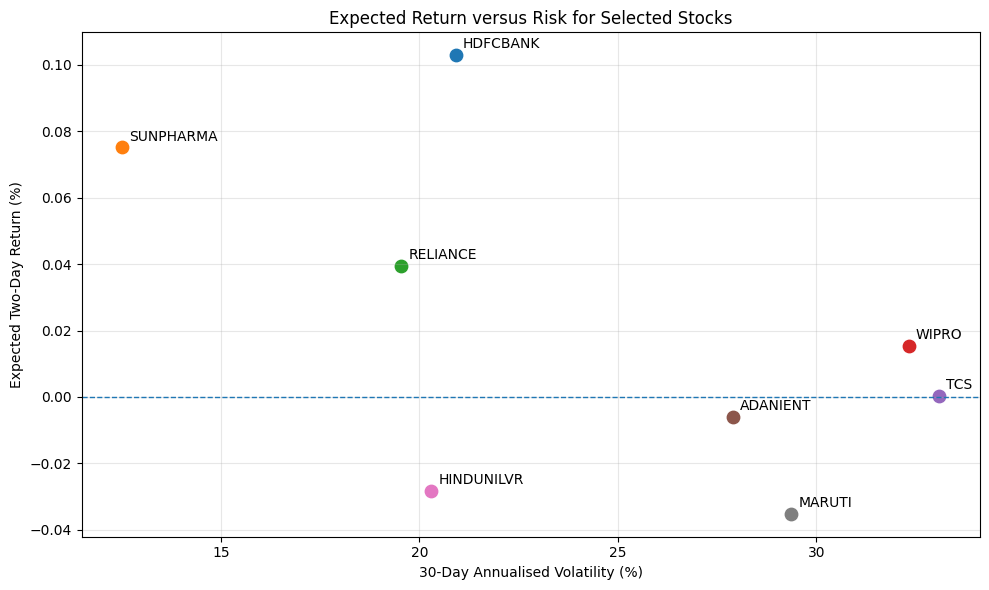

Final stock comparison created successfully.


In [23]:
# ============================================================
# FINAL MULTI-STOCK COMPARISON TABLE
# ============================================================

stock_comparison = multi_stock_model_results.copy()

# ------------------------------------------------------------
# Identify the best model for each stock
# ------------------------------------------------------------

model_rmse_columns = {
    "Naive": "Naive RMSE",
    "ARIMA": "ARIMA RMSE",
    "ETS": "ETS RMSE",
    "Ensemble": "Ensemble RMSE",
}

rmse_columns = list(model_rmse_columns.values())

# Find the column with the lowest RMSE
stock_comparison["Best RMSE Column"] = stock_comparison[rmse_columns].idxmin(axis=1)

# Convert the RMSE column name into a simple model name
rmse_to_model = {value: key for key, value in model_rmse_columns.items()}

stock_comparison["Best Model"] = stock_comparison["Best RMSE Column"].map(rmse_to_model)

stock_comparison["Best RMSE"] = stock_comparison[rmse_columns].min(axis=1)

# Improvement of the best model over the naive baseline
stock_comparison["Improvement vs Naive (%)"] = (
    (stock_comparison["Naive RMSE"] - stock_comparison["Best RMSE"])
    / stock_comparison["Naive RMSE"]
    * 100
)

# ------------------------------------------------------------
# Create forecast-direction signal
# ------------------------------------------------------------

stock_comparison["Forecast Signal"] = np.select(
    [
        stock_comparison["Expected Return (%)"] > 0,
        stock_comparison["Expected Return (%)"] < 0,
    ],
    [
        "Positive",
        "Negative",
    ],
    default="Neutral",
)

# ------------------------------------------------------------
# Create relative volatility categories
# ------------------------------------------------------------

low_volatility_limit = stock_comparison["30-Day Volatility (%)"].quantile(0.33)

high_volatility_limit = stock_comparison["30-Day Volatility (%)"].quantile(0.67)

stock_comparison["Risk Category"] = np.select(
    [
        stock_comparison["30-Day Volatility (%)"] <= low_volatility_limit,
        stock_comparison["30-Day Volatility (%)"] >= high_volatility_limit,
    ],
    [
        "Low",
        "High",
    ],
    default="Moderate",
)

# ------------------------------------------------------------
# Select final columns
# ------------------------------------------------------------

final_stock_comparison = (
    stock_comparison[
        [
            "Ticker",
            "Company",
            "Sector",
            "Latest Price",
            "Best ARIMA Order",
            "Best Model",
            "Best RMSE",
            "Improvement vs Naive (%)",
            "Ensemble MAPE (%)",
            "Ensemble Direction (%)",
            "Day 1 Forecast",
            "Day 2 Forecast",
            "Expected Return (%)",
            "Forecast Signal",
            "30-Day Volatility (%)",
            "90-Day Volatility (%)",
            "Risk Category",
            "Trend",
        ]
    ]
    .sort_values(
        "Expected Return (%)",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("FINAL MULTI-STOCK COMPARISON")

display(
    final_stock_comparison.round(
        {
            "Latest Price": 2,
            "Best RMSE": 3,
            "Improvement vs Naive (%)": 3,
            "Ensemble MAPE (%)": 3,
            "Ensemble Direction (%)": 2,
            "Day 1 Forecast": 2,
            "Day 2 Forecast": 2,
            "Expected Return (%)": 3,
            "30-Day Volatility (%)": 2,
            "90-Day Volatility (%)": 2,
        }
    )
)

# ------------------------------------------------------------
# Forecast-return versus volatility graph
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for _, row in final_stock_comparison.iterrows():

    ticker_label = row["Ticker"].replace(".NS", "")

    plt.scatter(
        row["30-Day Volatility (%)"],
        row["Expected Return (%)"],
        s=80,
    )

    plt.annotate(
        ticker_label,
        (
            row["30-Day Volatility (%)"],
            row["Expected Return (%)"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("30-Day Annualised Volatility (%)")
plt.ylabel("Expected Two-Day Return (%)")
plt.title("Expected Return versus Risk for Selected Stocks")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Final stock comparison created successfully.")


## Current portfolio allocation

This section uses the latest full-sample forecasts to illustrate how ₹10,00,000 could be allocated. These current weights are **not** used for the historical backtest.


,Ticker,Company,Sector,Expected Return (%),30-Day Volatility (%),Equal Weight,Strategy A Weight,Strategy B Weight,Combined Weight,Trade Price,Allocated Capital,Estimated Quantity,Invested Amount
0,HDFCBANK.NS,HDFC Bank,Banking,0.103,20.92,12.5,31.03,13.31,23.94,819.6,239442.42,292,239323.19
1,SUNPHARMA.NS,Sun Pharmaceutical,Pharmaceuticals,0.075,12.52,12.5,24.79,22.24,23.77,1932.6,237705.89,122,235777.20
2,RELIANCE.NS,Reliance Industries,Energy,0.040,19.55,12.5,16.79,14.25,15.77,1327.2,157726.42,118,156609.59
3,WIPRO.NS,Wipro,Information Technology,0.015,32.33,12.5,11.34,8.61,10.25,176.0,102479.09,582,102432.00
4,TCS.NS,Tata Consultancy Services,Information Technology,0.000,33.10,12.5,7.98,8.41,8.15,2269.0,81531.80,35,79415.00
5,ADANIENT.NS,Adani Enterprises,Infrastructure,-0.006,27.90,12.5,6.54,9.98,7.92,3160.7,79153.85,25,79017.50
6,HINDUNILVR.NS,Hindustan Unilever,FMCG,-0.028,20.31,12.5,1.53,13.71,6.40,2143.8,64036.64,29,62170.20
7,MARUTI.NS,Maruti Suzuki,Automobile,-0.035,29.37,12.5,0.00,9.48,3.79,13803.0,37923.89,2,27606.00


Total portfolio capital: ₹1,000,000.00
Estimated amount invested: ₹982,350.68
Unallocated cash: ₹17,649.32
Combined weights total: 100.0 %


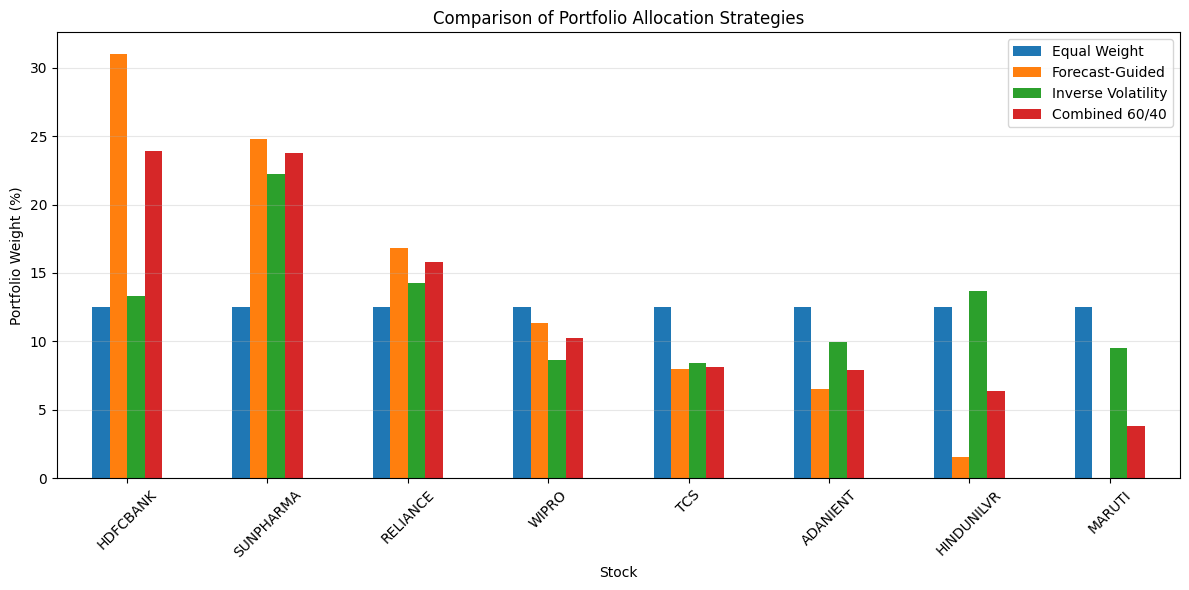

Portfolio allocation completed successfully.


In [24]:
# ============================================================
# PORTFOLIO CONSTRUCTION AND CAPITAL ALLOCATION
# ============================================================

portfolio_capital = 1_000_000

portfolio_allocation = final_stock_comparison.copy()

number_of_stocks = len(portfolio_allocation)

# ------------------------------------------------------------
# Benchmark: Equal-weight portfolio
# ------------------------------------------------------------

portfolio_allocation["Equal Weight"] = 1 / number_of_stocks

# ------------------------------------------------------------
# Strategy A: Forecast-guided allocation
# ------------------------------------------------------------
# Shift expected returns into a positive range while
# preserving their relative ranking.

expected_returns = portfolio_allocation["Expected Return (%)"].astype(float)

shifted_returns = expected_returns - expected_returns.min() + 1e-6

if shifted_returns.sum() == 0:
    forecast_weights = np.repeat(
        1 / number_of_stocks,
        number_of_stocks,
    )
else:
    forecast_weights = shifted_returns / shifted_returns.sum()

portfolio_allocation["Strategy A Weight"] = forecast_weights

# ------------------------------------------------------------
# Strategy B: Inverse-volatility allocation
# ------------------------------------------------------------

inverse_volatility = 1 / portfolio_allocation["30-Day Volatility (%)"]

portfolio_allocation["Strategy B Weight"] = (
    inverse_volatility / inverse_volatility.sum()
)

# ------------------------------------------------------------
# Combined allocation: 60% forecast + 40% volatility
# ------------------------------------------------------------

portfolio_allocation["Combined Weight"] = (
    0.60 * portfolio_allocation["Strategy A Weight"]
    + 0.40 * portfolio_allocation["Strategy B Weight"]
)

# Re-normalise for numerical safety
portfolio_allocation["Combined Weight"] = (
    portfolio_allocation["Combined Weight"]
    / portfolio_allocation["Combined Weight"].sum()
)

# ------------------------------------------------------------
# Use latest unadjusted closing price for quantities
# ------------------------------------------------------------

try:
    latest_trade_prices = (
        multi_stock_raw["Close"]
        .ffill()
        .iloc[-1]
        .reindex(portfolio_allocation["Ticker"])
    )

    portfolio_allocation["Trade Price"] = latest_trade_prices.values

except Exception:
    # Fallback to adjusted price
    portfolio_allocation["Trade Price"] = portfolio_allocation["Latest Price"]

# ------------------------------------------------------------
# Capital and estimated quantities
# ------------------------------------------------------------

portfolio_allocation["Allocated Capital"] = (
    portfolio_allocation["Combined Weight"] * portfolio_capital
)

portfolio_allocation["Estimated Quantity"] = np.floor(
    portfolio_allocation["Allocated Capital"] / portfolio_allocation["Trade Price"]
).astype(int)

portfolio_allocation["Invested Amount"] = (
    portfolio_allocation["Estimated Quantity"] * portfolio_allocation["Trade Price"]
)

total_invested = portfolio_allocation["Invested Amount"].sum()

unallocated_cash = portfolio_capital - total_invested

# ------------------------------------------------------------
# Final allocation table
# ------------------------------------------------------------

final_portfolio_allocation = (
    portfolio_allocation[
        [
            "Ticker",
            "Company",
            "Sector",
            "Expected Return (%)",
            "30-Day Volatility (%)",
            "Equal Weight",
            "Strategy A Weight",
            "Strategy B Weight",
            "Combined Weight",
            "Trade Price",
            "Allocated Capital",
            "Estimated Quantity",
            "Invested Amount",
        ]
    ]
    .sort_values(
        "Combined Weight",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Convert weights to percentages for display
display_portfolio = final_portfolio_allocation.copy()

weight_columns = [
    "Equal Weight",
    "Strategy A Weight",
    "Strategy B Weight",
    "Combined Weight",
]

for column in weight_columns:
    display_portfolio[column] *= 100

display(
    display_portfolio.round(
        {
            "Expected Return (%)": 3,
            "30-Day Volatility (%)": 2,
            "Equal Weight": 2,
            "Strategy A Weight": 2,
            "Strategy B Weight": 2,
            "Combined Weight": 2,
            "Trade Price": 2,
            "Allocated Capital": 2,
            "Invested Amount": 2,
        }
    )
)

print(f"Total portfolio capital: ₹{portfolio_capital:,.2f}")

print(f"Estimated amount invested: ₹{total_invested:,.2f}")

print(f"Unallocated cash: ₹{unallocated_cash:,.2f}")

print(
    "Combined weights total:",
    round(
        final_portfolio_allocation["Combined Weight"].sum() * 100,
        2,
    ),
    "%",
)

# ------------------------------------------------------------
# Allocation comparison graph
# ------------------------------------------------------------

allocation_plot = display_portfolio.set_index("Ticker")[
    [
        "Equal Weight",
        "Strategy A Weight",
        "Strategy B Weight",
        "Combined Weight",
    ]
]

allocation_plot.index = allocation_plot.index.str.replace(".NS", "", regex=False)

allocation_plot.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.ylabel("Portfolio Weight (%)")
plt.xlabel("Stock")
plt.title("Comparison of Portfolio Allocation Strategies")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(
    [
        "Equal Weight",
        "Forecast-Guided",
        "Inverse Volatility",
        "Combined 60/40",
    ]
)
plt.tight_layout()
plt.show()

print("Portfolio allocation completed successfully.")


## Out-of-sample portfolio backtest

To prevent look-ahead bias, portfolio inputs and weights are calculated from the first 80% of observations and then frozen during the final 20% test period.


In [25]:
# ============================================================
# OUT-OF-SAMPLE PORTFOLIO BACKTEST
# ============================================================

backtest_split_index = int(len(multi_stock_prices) * 0.80)

portfolio_train_prices = multi_stock_prices.iloc[:backtest_split_index].copy()

portfolio_test_prices = multi_stock_prices.iloc[backtest_split_index:].copy()

print(
    "Training period:",
    portfolio_train_prices.index.min().date(),
    "to",
    portfolio_train_prices.index.max().date(),
)

print(
    "Backtest period:",
    portfolio_test_prices.index.min().date(),
    "to",
    portfolio_test_prices.index.max().date(),
)

# ============================================================
# CALCULATE TRAINING-PERIOD PORTFOLIO INPUTS
# ============================================================

backtest_input_rows = []

for ticker in stock_tickers:

    training_series = portfolio_train_prices[ticker].dropna().astype(float)

    # Select ARIMA order using training data only
    selected_order = select_best_arima_order(training_series.values)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        training_arima = ARIMA(
            training_series.values,
            order=selected_order,
        ).fit()

        training_ets = StateSpaceETS(
            training_series.values,
            trend=True,
            damped_trend=True,
            initialization_method="estimated",
        ).fit(disp=False)

    arima_forecast = np.asarray(training_arima.forecast(2))

    ets_forecast = np.asarray(training_ets.forecast(2))

    ensemble_forecast = (arima_forecast + ets_forecast) / 2

    training_last_price = training_series.iloc[-1]

    predicted_return = ((ensemble_forecast[-1] / training_last_price) - 1) * 100

    training_log_returns = np.log(training_series / training_series.shift(1)).dropna()

    training_volatility = training_log_returns.tail(30).std() * np.sqrt(252) * 100

    backtest_input_rows.append(
        {
            "Ticker": ticker,
            "Training Last Price": training_last_price,
            "ARIMA Order": str(selected_order),
            "Predicted Return (%)": predicted_return,
            "30-Day Volatility (%)": training_volatility,
        }
    )


backtest_inputs = pd.DataFrame(backtest_input_rows).set_index("Ticker")

display(backtest_inputs.round(3))

# ============================================================
# CREATE BACKTEST PORTFOLIO WEIGHTS
# ============================================================

number_of_stocks = len(stock_tickers)

# Equal-weight strategy
equal_backtest_weights = pd.Series(
    1 / number_of_stocks,
    index=stock_tickers,
)

# Forecast-guided strategy
training_forecasts = backtest_inputs["Predicted Return (%)"]

positive_forecast_scores = training_forecasts - training_forecasts.min() + 1e-6

forecast_backtest_weights = positive_forecast_scores / positive_forecast_scores.sum()

# Inverse-volatility strategy
inverse_training_volatility = 1 / backtest_inputs["30-Day Volatility (%)"]

volatility_backtest_weights = (
    inverse_training_volatility / inverse_training_volatility.sum()
)

# Combined 60/40 strategy
combined_backtest_weights = (
    0.60 * forecast_backtest_weights + 0.40 * volatility_backtest_weights
)

combined_backtest_weights = combined_backtest_weights / combined_backtest_weights.sum()

backtest_weights = pd.DataFrame(
    {
        "Equal Weight": equal_backtest_weights,
        "Forecast-Guided": forecast_backtest_weights,
        "Inverse Volatility": volatility_backtest_weights,
        "Combined 60/40": combined_backtest_weights,
    }
)

display((backtest_weights * 100).round(2).rename_axis("Ticker"))


Training period: 2021-01-01 to 2025-06-11
Backtest period: 2025-06-12 to 2026-07-17


,Training Last Price,ARIMA Order,Predicted Return (%),30-Day Volatility (%)
Ticker,,,,
RELIANCE.NS,1436.495,"(2, 1, 2)",-0.011,19.801
HDFCBANK.NS,946.539,"(2, 1, 2)",0.060,16.903
TCS.NS,3322.241,"(0, 1, 0)",0.000,21.072
SUNPHARMA.NS,1669.802,"(2, 1, 2)",-0.024,19.340
MARUTI.NS,12318.670,"(2, 1, 1)",-0.052,22.631
HINDUNILVR.NS,2309.833,"(0, 1, 2)",0.020,15.573
ADANIENT.NS,2578.768,"(2, 1, 2)",0.104,36.922
WIPRO.NS,247.535,"(2, 1, 2)",-0.012,23.678


,Equal Weight,Forecast-Guided,Inverse Volatility,Combined 60/40
Ticker,,,,
RELIANCE.NS,12.5,8.20,13.07,10.15
HDFCBANK.NS,12.5,22.29,15.31,19.50
TCS.NS,12.5,10.38,12.28,11.14
SUNPHARMA.NS,12.5,5.66,13.38,8.75
MARUTI.NS,12.5,0.00,11.43,4.57
HINDUNILVR.NS,12.5,14.43,16.61,15.30
ADANIENT.NS,12.5,31.14,7.01,21.48
WIPRO.NS,12.5,7.89,10.93,9.10


BACKTEST FINAL PORTFOLIO VALUES


,Strategy,Final Value,Total Return (%)
1,Forecast-Guided,986922.78,-1.31
3,Combined 60/40,970004.01,-3.00
0,Equal Weight,959014.24,-4.10
2,Inverse Volatility,944625.85,-5.54


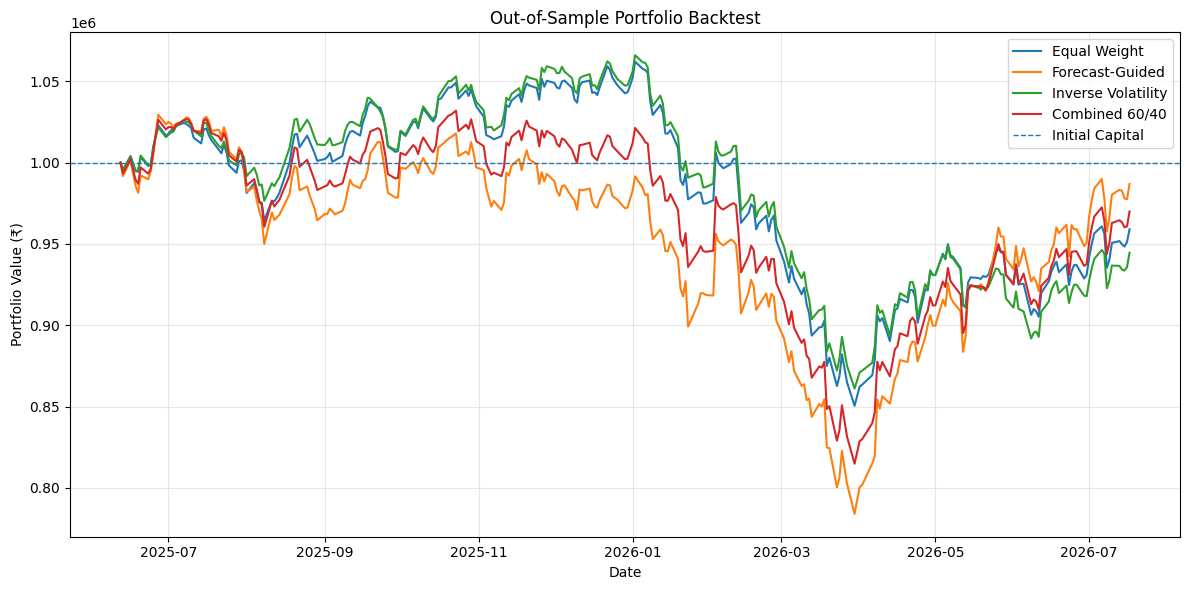

Out-of-sample portfolio backtest completed successfully.


In [26]:
# ============================================================
# RUN BUY-AND-HOLD BACKTEST
# ============================================================

initial_backtest_capital = 1_000_000

# Normalise each stock to 1 at the beginning of the test period
asset_growth = portfolio_test_prices / portfolio_test_prices.iloc[0]

portfolio_value_series = pd.DataFrame(index=asset_growth.index)

for strategy in backtest_weights.columns:

    strategy_weights = backtest_weights[strategy].reindex(asset_growth.columns)

    portfolio_value_series[strategy] = initial_backtest_capital * asset_growth.mul(
        strategy_weights,
        axis=1,
    ).sum(axis=1)

portfolio_daily_returns = portfolio_value_series.pct_change().dropna()

print("BACKTEST FINAL PORTFOLIO VALUES")

backtest_final_values = pd.DataFrame(
    {
        "Strategy": portfolio_value_series.columns,
        "Final Value": portfolio_value_series.iloc[-1].values,
    }
)

backtest_final_values["Total Return (%)"] = (
    (backtest_final_values["Final Value"] / initial_backtest_capital) - 1
) * 100

display(
    backtest_final_values.sort_values(
        "Total Return (%)",
        ascending=False,
    ).round(2)
)

plt.figure(figsize=(12, 6))

for strategy in portfolio_value_series.columns:
    plt.plot(
        portfolio_value_series.index,
        portfolio_value_series[strategy],
        label=strategy,
    )

plt.axhline(
    initial_backtest_capital,
    linestyle="--",
    linewidth=1,
    label="Initial Capital",
)

plt.title("Out-of-Sample Portfolio Backtest")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Out-of-sample portfolio backtest completed successfully.")


## Nifty 50 benchmark and risk metrics

All portfolios and the Nifty 50 are rebased to the same starting capital. Performance is compared using total return, annualised return, volatility, a zero-risk-free-rate Sharpe ratio and maximum drawdown.


In [27]:
# ============================================================
# DOWNLOAD NIFTY 50 BENCHMARK
# ============================================================

benchmark_start = portfolio_test_prices.index.min()
benchmark_end = portfolio_test_prices.index.max() + pd.Timedelta(days=1)

nifty_raw = yf.download(
    "^NSEI",
    start=benchmark_start,
    end=benchmark_end,
    auto_adjust=False,
    progress=False,
)

if nifty_raw.empty:
    raise RuntimeError("Nifty 50 benchmark data could not be downloaded.")

# Handle normal and MultiIndex column formats
if isinstance(nifty_raw.columns, pd.MultiIndex):

    if "Adj Close" in nifty_raw.columns.get_level_values(0):
        nifty_price = nifty_raw["Adj Close"].iloc[:, 0]
    else:
        nifty_price = nifty_raw["Close"].iloc[:, 0]

else:

    if "Adj Close" in nifty_raw.columns:
        nifty_price = nifty_raw["Adj Close"]
    else:
        nifty_price = nifty_raw["Close"]

nifty_price = nifty_price.dropna().astype(float).rename("Nifty 50")

# Convert Nifty price into a ₹10,00,000 investment
nifty_value = initial_backtest_capital * nifty_price / nifty_price.iloc[0]

nifty_value.name = "Nifty 50"

# Join portfolios and benchmark on common trading dates
comparison_value_series = portfolio_value_series.join(nifty_value, how="inner").dropna()

# Rebase everything to the same starting capital
comparison_value_series = (
    comparison_value_series / comparison_value_series.iloc[0] * initial_backtest_capital
)

print(
    "Comparison period:",
    comparison_value_series.index.min().date(),
    "to",
    comparison_value_series.index.max().date(),
)

display(comparison_value_series.head())


Comparison period: 2025-06-12 to 2026-07-17


,Equal Weight,Forecast-Guided,Inverse Volatility,Combined 60/40,Nifty 50
Date,,,,,
2025-06-12,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06
2025-06-13,9.956390e+05,9.917268e+05,9.956604e+05,9.933002e+05,9.931855e+05
2025-06-16,1.004045e+06,1.001533e+06,1.003417e+06,1.002286e+06,1.002343e+06
2025-06-17,9.991923e+05,9.931715e+05,9.994227e+05,9.956720e+05,9.986018e+05
2025-06-18,9.946699e+05,9.856585e+05,9.950197e+05,9.894030e+05,9.969404e+05


In [28]:
# ============================================================
# PORTFOLIO PERFORMANCE METRICS
# ============================================================


def calculate_portfolio_performance(value_series):
    """
    Calculate return and risk measures for one portfolio.

    Sharpe ratio uses a zero risk-free rate.
    """

    value_series = pd.Series(value_series).dropna().astype(float)

    daily_returns = value_series.pct_change().dropna()

    total_return = value_series.iloc[-1] / value_series.iloc[0] - 1

    number_of_days = len(daily_returns)

    annualised_return = (value_series.iloc[-1] / value_series.iloc[0]) ** (
        252 / number_of_days
    ) - 1

    annualised_volatility = daily_returns.std() * np.sqrt(252)

    if daily_returns.std() == 0:
        sharpe_ratio = np.nan
    else:
        sharpe_ratio = daily_returns.mean() / daily_returns.std() * np.sqrt(252)

    running_peak = value_series.cummax()

    drawdown = value_series / running_peak - 1

    maximum_drawdown = drawdown.min()

    return {
        "Final Value": value_series.iloc[-1],
        "Total Return (%)": total_return * 100,
        "Annualised Return (%)": annualised_return * 100,
        "Annualised Volatility (%)": annualised_volatility * 100,
        "Sharpe Ratio (Rf=0)": sharpe_ratio,
        "Maximum Drawdown (%)": maximum_drawdown * 100,
    }


performance_rows = []

for strategy in comparison_value_series.columns:

    strategy_metrics = calculate_portfolio_performance(
        comparison_value_series[strategy]
    )

    strategy_metrics["Strategy"] = strategy

    performance_rows.append(strategy_metrics)


portfolio_performance_summary = (
    pd.DataFrame(performance_rows)[
        [
            "Strategy",
            "Final Value",
            "Total Return (%)",
            "Annualised Return (%)",
            "Annualised Volatility (%)",
            "Sharpe Ratio (Rf=0)",
            "Maximum Drawdown (%)",
        ]
    ]
    .sort_values(
        "Total Return (%)",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("PORTFOLIO AND NIFTY 50 PERFORMANCE")

display(
    portfolio_performance_summary.round(
        {
            "Final Value": 2,
            "Total Return (%)": 2,
            "Annualised Return (%)": 2,
            "Annualised Volatility (%)": 2,
            "Sharpe Ratio (Rf=0)": 3,
            "Maximum Drawdown (%)": 2,
        }
    )
)


PORTFOLIO AND NIFTY 50 PERFORMANCE


,Strategy,Final Value,Total Return (%),Annualised Return (%),Annualised Volatility (%),Sharpe Ratio (Rf=0),Maximum Drawdown (%)
0,Forecast-Guided,986922.78,-1.31,-1.22,16.69,0.009,-23.83
1,Nifty 50,977744.54,-2.23,-2.08,12.89,-0.099,-15.18
2,Combined 60/40,970004.01,-3.00,-2.80,14.79,-0.119,-21.03
3,Equal Weight,959014.24,-4.10,-3.83,13.59,-0.220,-19.92
4,Inverse Volatility,944625.85,-5.54,-5.18,12.97,-0.345,-19.22


## Final conclusion and export

FINAL PROJECT SUMMARY


,Project Result,Value
0,Best total-return strategy,Forecast-Guided
1,Best strategy total return,-1.31%
2,Nifty 50 total return,-2.23%
3,Forecast strategy outperformance vs Nifty,0.92 percentage points
4,Highest Sharpe-ratio strategy,Forecast-Guided
5,Lowest-volatility investment,Nifty 50
6,Smallest maximum drawdown,Nifty 50
7,Combined portfolio total return,-3.00%
8,Equal-weight portfolio total return,-4.10%
9,Inverse-volatility portfolio total return,-5.54%



FINAL PROJECT CONCLUSION

This project developed an end-to-end time-series forecasting and
risk-aware portfolio analysis pipeline for eight NSE stocks.

The forecasting stage compared Naive, ARIMA, ETS and ARIMA-ETS
Ensemble models using walk-forward validation. The results showed
that the advanced models produced only marginal improvements over
the naive baseline, while directional accuracy remained close to
random for several stocks.

During the out-of-sample portfolio backtest, the Forecast-Guided
strategy achieved the highest total return of
-1.31%.

The Nifty 50 benchmark returned
-2.23% over the same period.

Therefore, the Forecast-Guided portfolio outperformed the Nifty 50
by approximately 0.92 percentage points.

However, the Forecast-Guided portfolio had annualised volatility of
16.69% and a maximum
drawdown of -23.83%, compared
with Nifty 50 volatility of
12.89% and maximum drawdown
of -15.18%.

The Combined 60/40 strategy balanced forecast information with
inverse-volatili

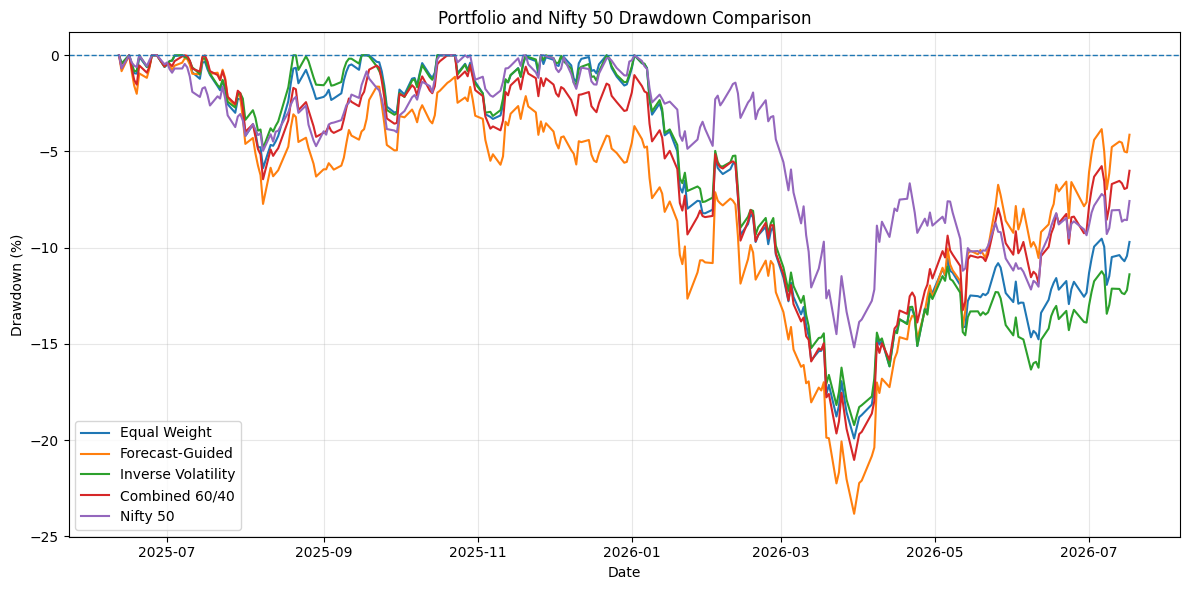

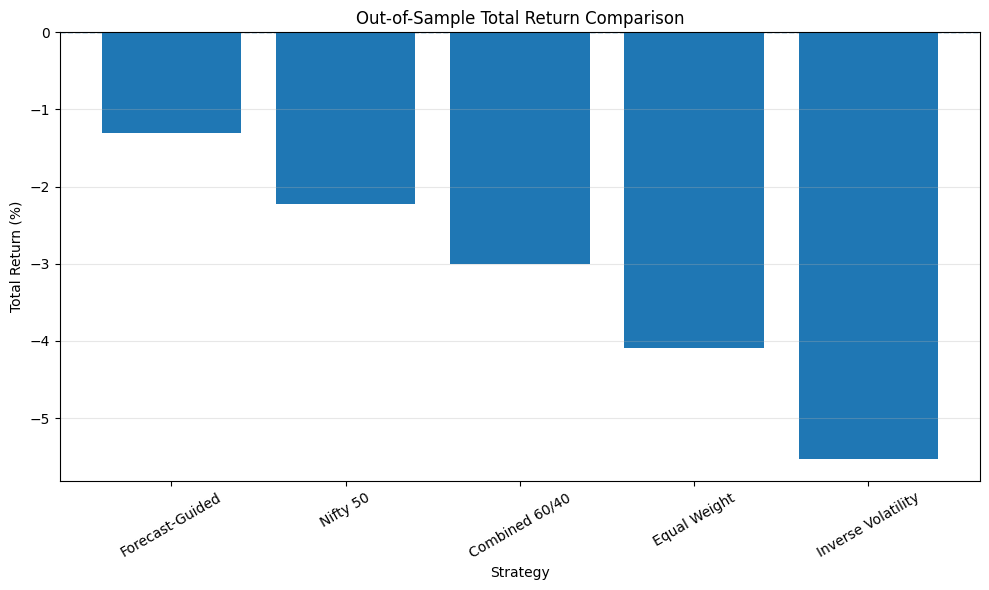


PROJECT COMPLETED SUCCESSFULLY
Files saved: 14
Results folder: time_series_project_outputs
ZIP file: /content/time_series_project_final_outputs.zip


In [29]:
# ============================================================
# STEP 42: FINAL PROJECT SUMMARY AND EXPORT
# ============================================================

OUTPUT_FOLDER = Path("time_series_project_outputs")
OUTPUT_FOLDER.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Extract important strategy results
# ------------------------------------------------------------

performance_table = portfolio_performance_summary.set_index("Strategy").copy()

forecast_row = performance_table.loc["Forecast-Guided"]

nifty_row = performance_table.loc["Nifty 50"]

combined_row = performance_table.loc["Combined 60/40"]

equal_row = performance_table.loc["Equal Weight"]

inverse_row = performance_table.loc["Inverse Volatility"]

forecast_outperformance = (
    forecast_row["Total Return (%)"] - nifty_row["Total Return (%)"]
)

# Strategy with highest total return
best_return_strategy = portfolio_performance_summary.sort_values(
    "Total Return (%)",
    ascending=False,
).iloc[0]

# Strategy with highest Sharpe ratio
best_sharpe_strategy = portfolio_performance_summary.sort_values(
    "Sharpe Ratio (Rf=0)",
    ascending=False,
).iloc[0]

# Strategy with lowest volatility
lowest_volatility_strategy = portfolio_performance_summary.sort_values(
    "Annualised Volatility (%)",
    ascending=True,
).iloc[0]

# Strategy with the smallest drawdown magnitude
smallest_drawdown_strategy = (
    portfolio_performance_summary.assign(
        DrawdownMagnitude=lambda table: table["Maximum Drawdown (%)"].abs()
    )
    .sort_values(
        "DrawdownMagnitude",
        ascending=True,
    )
    .iloc[0]
)

# ------------------------------------------------------------
# Final summary table
# ------------------------------------------------------------

final_project_summary = pd.DataFrame(
    {
        "Project Result": [
            "Best total-return strategy",
            "Best strategy total return",
            "Nifty 50 total return",
            "Forecast strategy outperformance vs Nifty",
            "Highest Sharpe-ratio strategy",
            "Lowest-volatility investment",
            "Smallest maximum drawdown",
            "Combined portfolio total return",
            "Equal-weight portfolio total return",
            "Inverse-volatility portfolio total return",
        ],
        "Value": [
            best_return_strategy["Strategy"],
            f"{best_return_strategy['Total Return (%)']:.2f}%",
            f"{nifty_row['Total Return (%)']:.2f}%",
            f"{forecast_outperformance:.2f} percentage points",
            best_sharpe_strategy["Strategy"],
            lowest_volatility_strategy["Strategy"],
            smallest_drawdown_strategy["Strategy"],
            f"{combined_row['Total Return (%)']:.2f}%",
            f"{equal_row['Total Return (%)']:.2f}%",
            f"{inverse_row['Total Return (%)']:.2f}%",
        ],
    }
)

print("FINAL PROJECT SUMMARY")

display(final_project_summary)

# ------------------------------------------------------------
# Automatically generated project conclusion
# ------------------------------------------------------------

final_conclusion = f"""
FINAL PROJECT CONCLUSION

This project developed an end-to-end time-series forecasting and
risk-aware portfolio analysis pipeline for eight NSE stocks.

The forecasting stage compared Naive, ARIMA, ETS and ARIMA-ETS
Ensemble models using walk-forward validation. The results showed
that the advanced models produced only marginal improvements over
the naive baseline, while directional accuracy remained close to
random for several stocks.

During the out-of-sample portfolio backtest, the Forecast-Guided
strategy achieved the highest total return of
{forecast_row['Total Return (%)']:.2f}%.

The Nifty 50 benchmark returned
{nifty_row['Total Return (%)']:.2f}% over the same period.

Therefore, the Forecast-Guided portfolio outperformed the Nifty 50
by approximately {forecast_outperformance:.2f} percentage points.

However, the Forecast-Guided portfolio had annualised volatility of
{forecast_row['Annualised Volatility (%)']:.2f}% and a maximum
drawdown of {forecast_row['Maximum Drawdown (%)']:.2f}%, compared
with Nifty 50 volatility of
{nifty_row['Annualised Volatility (%)']:.2f}% and maximum drawdown
of {nifty_row['Maximum Drawdown (%)']:.2f}%.

The Combined 60/40 strategy balanced forecast information with
inverse-volatility allocation, but it did not outperform the
Forecast-Guided strategy or the Nifty 50 during the test period.

The project demonstrates that statistical forecasting can support
portfolio decisions, but historical price data alone is not
sufficient for consistently accurate market-direction prediction.
Future improvements should include financial news sentiment,
macroeconomic variables, transaction costs and periodic portfolio
rebalancing.

This analysis is an educational statistical project and should not
be interpreted as financial or investment advice.
"""

print(final_conclusion)

# ------------------------------------------------------------
# Save important tables
# ------------------------------------------------------------

# Time-indexed tables retain their dates; summary tables do not receive
# an unnecessary extra index column.
tables_to_save = {
    "multi_stock_prices.csv": (multi_stock_prices, True),
    "multi_stock_stationarity_volatility.csv": (multi_stock_summary, False),
    "multi_stock_model_results.csv": (multi_stock_model_results, False),
    "final_stock_comparison.csv": (final_stock_comparison, False),
    "current_portfolio_allocation.csv": (final_portfolio_allocation, False),
    "backtest_inputs.csv": (backtest_inputs.reset_index(), False),
    "backtest_weights.csv": (backtest_weights.reset_index(), False),
    "backtest_portfolio_values.csv": (portfolio_value_series, True),
    "portfolio_and_nifty_values.csv": (comparison_value_series, True),
    "portfolio_performance_summary.csv": (portfolio_performance_summary, False),
    "final_project_summary.csv": (final_project_summary, False),
}

saved_files = []
for filename, (dataframe, keep_index) in tables_to_save.items():
    dataframe.to_csv(OUTPUT_FOLDER / filename, index=keep_index)
    saved_files.append(filename)

# ------------------------------------------------------------
# Save final conclusion as text
# ------------------------------------------------------------

conclusion_path = OUTPUT_FOLDER / "final_project_conclusion.txt"

with open(
    conclusion_path,
    "w",
    encoding="utf-8",
) as conclusion_file:

    conclusion_file.write(final_conclusion.strip())

saved_files.append("final_project_conclusion.txt")

# ------------------------------------------------------------
# Drawdown graph
# ------------------------------------------------------------

drawdown_series = (comparison_value_series / comparison_value_series.cummax() - 1) * 100

plt.figure(figsize=(12, 6))

for strategy in drawdown_series.columns:

    plt.plot(
        drawdown_series.index,
        drawdown_series[strategy],
        label=strategy,
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.title("Portfolio and Nifty 50 Drawdown Comparison")

plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

drawdown_graph_path = OUTPUT_FOLDER / "portfolio_drawdown_comparison.png"

plt.savefig(
    drawdown_graph_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

saved_files.append("portfolio_drawdown_comparison.png")

# ------------------------------------------------------------
# Total-return comparison graph
# ------------------------------------------------------------

return_plot_data = portfolio_performance_summary.sort_values(
    "Total Return (%)",
    ascending=False,
)

plt.figure(figsize=(10, 6))

plt.bar(
    return_plot_data["Strategy"],
    return_plot_data["Total Return (%)"],
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.title("Out-of-Sample Total Return Comparison")

plt.xlabel("Strategy")
plt.ylabel("Total Return (%)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

return_graph_path = OUTPUT_FOLDER / "total_return_comparison.png"

plt.savefig(
    return_graph_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

saved_files.append("total_return_comparison.png")

# ------------------------------------------------------------
# Create one ZIP file containing all results
# ------------------------------------------------------------

zip_file_path = shutil.make_archive(
    "time_series_project_final_outputs",
    "zip",
    str(OUTPUT_FOLDER),
)

print("\nPROJECT COMPLETED SUCCESSFULLY")

print(
    "Files saved:",
    len(saved_files),
)

print(
    "Results folder:",
    str(OUTPUT_FOLDER),
)

print(
    "ZIP file:",
    zip_file_path,
)


## Project limitations and recommended improvements

- Forecasts use historical prices only; earnings, macroeconomic variables and news sentiment are not included.
- The portfolio backtest uses fixed buy-and-hold weights with no transaction costs or taxes.
- The forecast-guided strategy is sensitive to very small predicted return differences.
- Results describe one fixed sample and should not be treated as investment advice.

Useful future extensions include rolling rebalancing, transaction costs, sentiment features, alternative risk-free rates and more robust portfolio constraints.
